# Financial Trading with Python, 2nd Edition
Cordell L. Tanny, CFA, FRM, FDP

## Chapter 4: Exploratory Data Analysis
### Notebook 4.1: EDA Fundamentals Lab

Version: 1

Date of last revision: January 25, 2026

This notebook covers the foundational techniques of exploratory data analysis: numerical summaries and essential visualizations. We will work with a broad dataset of 10 asset class ETFs to learn techniques that apply to any portfolio analysis.

*Note and recommendation: Very often, you might want to experiment on your own as you go through this notebook. We recommend you save a copy of this notebook before you start adding cells or changing anything. This way you always have a pristine copy to go back to.*

---

## Setup

In [1]:
# Install packages if needed (uncomment if running in Colab)
# !pip install yfinance seaborn plotly --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings

# Display settings
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"seaborn version: {sns.__version__}")

pandas version: 2.2.2
numpy version: 2.0.2
seaborn version: 0.13.2


---

## Section 1: Data Download

For this notebook, we will use a broad set of 10 ETFs representing major asset classes. This gives us enough diversity to demonstrate correlation analysis, compare distributions across different asset types, and create meaningful visualizations.

| Ticker | Description | Asset Class |
|--------|-------------|-------------|
| SPY | S&P 500 | US Large Cap Equity |
| IWM | Russell 2000 | US Small Cap Equity |
| EFA | MSCI EAFE | Developed International Equity |
| EEM | MSCI Emerging Markets | Emerging Markets Equity |
| TLT | 20+ Year Treasury | Long-Term US Government Bonds |
| GOVT | US Treasury Broad | US Government Bonds |
| LQD | Investment Grade Corporate | US Corporate Bonds |
| IGOV | International Treasury | International Government Bonds |
| IBND | International Corporate | International Corporate Bonds |
| GLD | Gold | Commodities |

We will download monthly data to keep the visualizations clean and reduce noise. Monthly data is also standard for strategic asset allocation analysis.

In [3]:
# Configuration
tickers = ['SPY', 'IWM', 'EFA', 'EEM', 'TLT', 'GOVT', 'LQD', 'IGOV', 'IBND', 'GLD']

# GOVT and IBND have 2012 inception - this is our binding constraint
start_date = '2012-01-01'
end_date = '2025-12-31'

print(f"Tickers: {tickers}")
print(f"Date range: {start_date} to {end_date}")

Tickers: ['SPY', 'IWM', 'EFA', 'EEM', 'TLT', 'GOVT', 'LQD', 'IGOV', 'IBND', 'GLD']
Date range: 2012-01-01 to 2025-12-31


In [4]:
# Download daily data
# Using auto_adjust=False to be consistent with Chapter 3
df_daily = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, progress=True)

print(f"\nDownloaded shape: {df_daily.shape}")

[*********************100%***********************]  10 of 10 completed


Downloaded shape: (3519, 60)


In [5]:
# Extract the Adjusted Close prices
df_prices_daily = df_daily['Adj Close'].copy()

# Check for any missing data
print("Missing values per ticker:")
print(df_prices_daily.isna().sum())

Missing values per ticker:
Ticker
EEM      0
EFA      0
GLD      0
GOVT    36
IBND     0
IGOV     0
IWM      0
LQD      0
SPY      0
TLT      0
dtype: int64


Some tickers have more missing values because they have later inception dates. Let's find the common start date where all tickers have data.

*Note: pandas comes with a built in method to find the first valid index (non NaN) from a series! We will use the `.apply` method to determine the first valid date for all ETFs.*

In [6]:
# Find first valid date for each ticker
first_valid = df_prices_daily.apply(lambda x: x.first_valid_index())
print("First valid date per ticker:")
print(first_valid.sort_values())

# Use the latest first valid date as our common start
common_start = first_valid.max()
print(f"\nCommon start date: {common_start.strftime('%Y-%m-%d')}")

First valid date per ticker:
Ticker
EEM    2012-01-03
EFA    2012-01-03
GLD    2012-01-03
IBND   2012-01-03
IGOV   2012-01-03
IWM    2012-01-03
LQD    2012-01-03
SPY    2012-01-03
TLT    2012-01-03
GOVT   2012-02-24
dtype: datetime64[ns]

Common start date: 2012-02-24


In [7]:
# Trim to common date range
df_prices_daily = df_prices_daily.loc[common_start:].copy()

# Verify no missing values
print(f"Date range: {df_prices_daily.index[0].strftime('%Y-%m-%d')} to {df_prices_daily.index[-1].strftime('%Y-%m-%d')}")
print(f"Shape: {df_prices_daily.shape}")
print(f"Missing values: {df_prices_daily.isna().sum().sum()}")

Date range: 2012-02-24 to 2025-12-30
Shape: (3483, 10)
Missing values: 0


### 1.1 Resample to Monthly

For EDA, monthly data provides cleaner visualizations with less noise. We resample by taking the last price of each month. For returns, we will calculate month-over-month percentage changes.

We will discuss resampling in greater detail in Chapter 5.

In [8]:
# Resample to month-end prices
df_prices = df_prices_daily.resample('ME').last()

print(f"Monthly data shape: {df_prices.shape}")
print(f"Date range: {df_prices.index[0].strftime('%Y-%m-%d')} to {df_prices.index[-1].strftime('%Y-%m-%d')}")
df_prices.head()

Monthly data shape: (167, 10)
Date range: 2012-02-29 to 2025-12-31


Ticker,EEM,EFA,GLD,GOVT,IBND,IGOV,IWM,LQD,SPY,TLT
Date,,,,,,,,,,
2012-02-29,32.6063,35.8645,164.2900,19.3513,28.9919,46.3829,66.9457,72.5090,107.0190,80.5705
2012-03-31,31.5912,36.0154,162.1200,19.2032,29.3988,45.8692,68.6092,71.4786,110.4612,77.1575
2012-04-30,31.0543,35.2674,161.8800,19.4490,29.2776,46.4518,67.4989,72.2520,109.7238,80.8875
2012-05-31,27.7297,31.3372,151.6200,19.8393,27.3471,44.8832,63.0581,72.7991,103.1342,88.1879
2012-06-30,29.1260,33.5443,155.1900,19.7370,28.0483,45.3182,66.2439,73.4335,107.3195,86.7079


We can calculate the monthly change in prices using the `.pct_change()` pandas method.

In [9]:
# Calculate monthly returns
df_returns = df_prices.pct_change().dropna()

print(f"Returns shape: {df_returns.shape}")
print(f"Date range: {df_returns.index[0].strftime('%Y-%m-%d')} to {df_returns.index[-1].strftime('%Y-%m-%d')}")
df_returns.head()

Returns shape: (166, 10)
Date range: 2012-03-31 to 2025-12-31


Ticker,EEM,EFA,GLD,GOVT,IBND,IGOV,IWM,LQD,SPY,TLT
Date,,,,,,,,,,
2012-03-31,-0.0311,0.0042,-0.0132,-0.0077,0.0140,-0.0111,0.0248,-0.0142,0.0322,-0.0424
2012-04-30,-0.0170,-0.0208,-0.0015,0.0128,-0.0041,0.0127,-0.0162,0.0108,-0.0067,0.0483
2012-05-31,-0.1071,-0.1114,-0.0634,0.0201,-0.0659,-0.0338,-0.0658,0.0076,-0.0601,0.0903
2012-06-30,0.0504,0.0704,0.0235,-0.0052,0.0256,0.0097,0.0505,0.0087,0.0406,-0.0168
2012-07-31,-0.0003,0.0008,0.0084,0.0099,0.0019,0.0105,-0.0152,0.0348,0.0118,0.0382


### 1.2 Save for Later Use

We save both prices and returns to parquet files so we can reload them quickly in the next notebook without re-downloading.

In [10]:
# Save to parquet
df_prices.to_parquet('broad_asset_prices.parquet')
df_returns.to_parquet('broad_asset_returns.parquet')

print("Saved: broad_asset_prices.parquet")
print("Saved: broad_asset_returns.parquet")

Saved: broad_asset_prices.parquet
Saved: broad_asset_returns.parquet


---

## Section 2: Numerical Summaries

Before creating any visualizations, we need to understand what we are working with. Numerical summaries give us the facts: how many observations, what data types, what are the key statistics. This is always the first step in any EDA process.

**When to use numerical summaries:**
- At the start of any analysis to understand your data
- To check for data quality issues (missing values, unexpected ranges)
- To get baseline statistics before diving into visualizations

**Key information you extract:**
- Data types and memory usage (`.info()`)
- Central tendency, spread, and range (`.describe()`)
- Distribution shape: skewness and kurtosis

### 2.1 The `.info()` Method

The `.info()` method shows you the basic structure of your data:
- How many rows and columns
- Data types for each column
- Non-null counts (to spot missing data)
- Memory usage

This should be the first thing you run on any new dataset.

In [11]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 166 entries, 2012-03-31 to 2025-12-31
Freq: ME
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EEM     166 non-null    float64
 1   EFA     166 non-null    float64
 2   GLD     166 non-null    float64
 3   GOVT    166 non-null    float64
 4   IBND    166 non-null    float64
 5   IGOV    166 non-null    float64
 6   IWM     166 non-null    float64
 7   LQD     166 non-null    float64
 8   SPY     166 non-null    float64
 9   TLT     166 non-null    float64
dtypes: float64(10)
memory usage: 14.3 KB


**What we learn:**
- We have 166 monthly observations (rows) for each of 10 assets (columns)
- All columns are `float64` (numeric), which is correct for return calculations
- All columns have 166 non-null values, confirming no missing data
- The DatetimeIndex confirms our time series structure with month-end frequency

If you see fewer non-null values than total rows, you have missing data to address. If you see unexpected data types (like `object` instead of `float64`), you may have data quality issues.

### 2.2 The `.describe()` Method

The `.describe()` method provides the five-number summary plus count, mean, and standard deviation. These statistics form the foundation for understanding your data's distribution.

| Statistic | What It Tells You |
|-----------|-------------------|
| count | Number of observations (check for missing data) |
| mean | Average value (central tendency) |
| std | Standard deviation (spread/volatility) |
| min | Smallest value |
| 25% | First quartile (25th percentile) |
| 50% | Median (middle value) |
| 75% | Third quartile (75th percentile) |
| max | Largest value |

In [12]:
# The five-number summary plus mean and std
df_returns.describe()

Ticker,EEM,EFA,GLD,GOVT,IBND,IGOV,IWM,LQD,SPY,TLT
count,166.0000,166.0000,166.0000,166.0000,166.0000,166.0000,166.0000,166.0000,166.0000,166.0000
mean,0.0042,0.0068,0.0063,0.0011,0.0010,-0.0003,0.0094,0.0028,0.0121,0.0012
std,0.0470,0.0417,0.0428,0.0130,0.0268,0.0246,0.0548,0.0218,0.0402,0.0383
min,-0.1577,-0.1411,-0.1106,-0.0341,-0.0773,-0.0760,-0.2148,-0.0670,-0.1249,-0.0942
25%,-0.0267,-0.0207,-0.0215,-0.0060,-0.0141,-0.0130,-0.0215,-0.0075,-0.0099,-0.0236
50%,0.0072,0.0111,-0.0007,-0.0001,0.0036,0.0012,0.0131,0.0023,0.0180,-0.0002
75%,0.0326,0.0322,0.0328,0.0085,0.0164,0.0141,0.0420,0.0134,0.0364,0.0211
max,0.1559,0.1427,0.1176,0.0349,0.0905,0.0793,0.1824,0.0757,0.1270,0.1105


**Reading the output - what to look for:**

- **Mean returns:** SPY shows the highest monthly mean at 1.21%, while IGOV is slightly negative at -0.03%. This tells you which assets have provided positive drift over the period.

- **Volatility (std):** IWM (small cap) has the highest monthly volatility at 5.48%, while GOVT (treasury bonds) has the lowest at 1.30%. The range between highest and lowest volatility is substantial.

- **Extremes (min/max):** IWM shows the widest range: -21.48% to +18.24% in a single month. Compare to GOVT: -3.41% to +3.49%. This illustrates the difference in tail risk across asset classes.

- **Median vs Mean:** When the median (50%) differs substantially from the mean, it suggests skewness in the distribution. For most of these assets, they are fairly close, but we will examine skewness explicitly in the next section.

**Tip:** Transposing the output can make it easier to read when you have many columns.

In [13]:
# Transposed view - each asset is now a row
df_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
EEM,166.0000,0.0042,0.0470,-0.1577,-0.0267,0.0072,0.0326,0.1559
EFA,166.0000,0.0068,0.0417,-0.1411,-0.0207,0.0111,0.0322,0.1427
GLD,166.0000,0.0063,0.0428,-0.1106,-0.0215,-0.0007,0.0328,0.1176
GOVT,166.0000,0.0011,0.0130,-0.0341,-0.0060,-0.0001,0.0085,0.0349
IBND,166.0000,0.0010,0.0268,-0.0773,-0.0141,0.0036,0.0164,0.0905
IGOV,166.0000,-0.0003,0.0246,-0.0760,-0.0130,0.0012,0.0141,0.0793
IWM,166.0000,0.0094,0.0548,-0.2148,-0.0215,0.0131,0.0420,0.1824
LQD,166.0000,0.0028,0.0218,-0.0670,-0.0075,0.0023,0.0134,0.0757
SPY,166.0000,0.0121,0.0402,-0.1249,-0.0099,0.0180,0.0364,0.1270


### 2.3 Extended Summary: The Four Moments

The `.describe()` method gives us the first two moments (mean and standard deviation) but misses two critical statistics for financial data: **skewness** and **kurtosis**.

| Moment | Statistic | What It Measures |
|--------|-----------|------------------|
| 1st | Mean | Location (central tendency) |
| 2nd | Std Dev | Spread (volatility) |
| 3rd | Skewness | Asymmetry (tail direction) |
| 4th | Kurtosis | Tail heaviness (extreme events) |

**Why these matter in finance:**
- **Skewness:** Negative skew means the left tail is longer - more extreme negative returns than positive ones. This is bad for investors. Positive skew means the opposite.
- **Kurtosis:** High kurtosis means fatter tails than a normal distribution - more extreme events than you would expect. Most financial returns exhibit this characteristic.

**Important note on kurtosis:** Pandas `.kurtosis()` returns **excess kurtosis** by default. This means:
- Excess kurtosis of 0 = normal distribution
- Positive values = fatter tails than normal (leptokurtic)
- Negative values = thinner tails than normal (platykurtic)

Some textbooks use "absolute kurtosis" where a normal distribution equals 3. Always check which convention is being used. In pandas, excess kurtosis = absolute kurtosis - 3.

In [14]:
# Extended summary with all four moments
extended_stats = df_returns.agg(['mean', 'std', 'min', 'max', 'skew', 'kurtosis']).T

# Rename for clarity
extended_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis']

# Sort by volatility to see risk ordering
extended_stats.sort_values('Std Dev', ascending=False)

,Mean,Std Dev,Min,Max,Skewness,Kurtosis
Ticker,,,,,,
IWM,0.0094,0.0548,-0.2148,0.1824,-0.3164,1.4537
EEM,0.0042,0.0470,-0.1577,0.1559,-0.0794,0.7964
GLD,0.0063,0.0428,-0.1106,0.1176,0.2186,-0.1579
EFA,0.0068,0.0417,-0.1411,0.1427,-0.2707,1.2054
SPY,0.0121,0.0402,-0.1249,0.1270,-0.4747,0.8963
TLT,0.0012,0.0383,-0.0942,0.1105,0.2894,0.2210
IBND,0.0010,0.0268,-0.0773,0.0905,-0.1501,0.9764
IGOV,-0.0003,0.0246,-0.0760,0.0793,-0.0983,0.9768
LQD,0.0028,0.0218,-0.0670,0.0757,-0.1056,1.5183


**Interpreting the extended summary:**

- **Skewness:** Most equity assets show negative skewness. SPY has the most negative skew at -0.47, meaning its worst months are more extreme than its best months. GLD (+0.22) and TLT (+0.29) show positive skew, meaning their upside surprises can exceed their downside.

- **Kurtosis:** Remember, pandas reports excess kurtosis where 0 equals a normal distribution. LQD has the highest excess kurtosis at 1.52, followed by IWM at 1.45. This means these assets experience more extreme moves than a normal distribution would predict. GLD is the only asset with negative excess kurtosis (-0.16), indicating its return distribution has thinner tails than normal.

**The practical takeaway:** These assets have varying degrees of non-normality. Risk models that assume normal distributions will underestimate the probability of extreme events, particularly for assets with high positive kurtosis and negative skewness like LQD and IWM.

### 2.4 Annualized Statistics

Monthly statistics are hard to interpret in isolation. We typically annualize returns and volatility to make them comparable to benchmarks and industry conventions.

- **Annualized return:** Monthly mean × 12
- **Annualized volatility:** Monthly std × √12

The square root of 12 scaling for volatility comes from the assumption that returns are independent over time (volatility scales with the square root of time).

In [15]:
# Annualized statistics
annual_stats = pd.DataFrame({
    'Ann. Return': df_returns.mean() * 12,
    'Ann. Volatility': df_returns.std() * np.sqrt(12),
    'Skewness': df_returns.skew(),
    'Kurtosis': df_returns.kurtosis()
})

# Add Sharpe ratio (assuming 0% risk-free rate for simplicity)
# The Sharpe Ratio will be discussed in greater detail in later chapters. Just understand
# it quantifies the amount of return earned for every unit of risk (standard deviation) taken.
annual_stats['Sharpe Ratio'] = annual_stats['Ann. Return'] / annual_stats['Ann. Volatility']

# Sort by Sharpe ratio
annual_stats.sort_values('Sharpe Ratio', ascending=False)

,Ann. Return,Ann. Volatility,Skewness,Kurtosis,Sharpe Ratio
Ticker,,,,,
SPY,0.1448,0.1393,-0.4747,0.8963,1.0397
IWM,0.1131,0.1900,-0.3164,1.4537,0.5955
EFA,0.0821,0.1445,-0.2707,1.2054,0.5685
GLD,0.0751,0.1484,0.2186,-0.1579,0.5063
LQD,0.0334,0.0754,-0.1056,1.5183,0.4431
EEM,0.0509,0.1629,-0.0794,0.7964,0.3125
GOVT,0.0138,0.0451,0.0572,0.5733,0.3049
IBND,0.0117,0.0929,-0.1501,0.9764,0.1258
TLT,0.0149,0.1325,0.2894,0.2210,0.1127


**What the annualized view reveals:**

- **SPY dominates:** SPY delivered 14.48% annualized return with 13.93% volatility, producing a Sharpe ratio of 1.04. This is exceptionally strong risk-adjusted performance.

- **Return-risk tradeoff:** IWM (small cap) had 11.31% return but 19.00% volatility, resulting in a Sharpe of only 0.60. Higher volatility did not translate to proportionally higher returns.

- **EEM disappointment:** Emerging markets returned only 5.09% with 16.29% volatility, giving a Sharpe of 0.31. This is poor compensation for the risk taken.

- **Bond characteristics:** GOVT has low return (1.38%) but also very low volatility (4.51%), giving it a Sharpe of 0.30. TLT has similar return (1.49%) but much higher volatility (13.25%), making its Sharpe ratio only 0.11.

- **Gold:** GLD shows 7.51% annualized return with 14.84% volatility, producing a respectable Sharpe of 0.51. Combined with its positive skewness and diversification properties, gold has served a useful portfolio role.

- **IGOV negative:** International government bonds (IGOV) is the only asset with negative returns (-0.40% annualized), producing the only negative Sharpe ratio (-0.05).

These are the numbers. In the next section, we will turn them into visualizations that make the patterns immediately visible.

---

## Section Summary

In this section, we covered:

1. **Data Download:** Retrieved 10 diversified ETFs representing major asset classes, resampled to monthly frequency.

2. **`.info()` Method:** Shows basic data structure including data types, counts, and memory usage.

3. **`.describe()` Method:** The five-number summary plus mean and standard deviation.

4. **Extended Summary:** Added skewness and kurtosis (the third and fourth moments) to assess distribution shape and tail risk. Note that pandas reports excess kurtosis where 0 equals normal.

5. **Annualized Statistics:** Scaled monthly numbers to annual for industry-standard comparisons and calculated Sharpe ratios.

**Key takeaway:** Always start with numerical summaries before visualizing. The numbers tell you what to look for in the charts.

In the next section, we will create time-series visualizations that bring these numbers to life.

*Note: Please do not forget to download you the parquet files from the Files section in this notebook. If you close this notebook, those files will be lost. You must download them for use in future notebooks.*

---

## Section 3: The Matplotlib Framework

Before we create visualizations, we need to understand how matplotlib works. Matplotlib offers two interfaces for creating plots, and choosing the right one will make your code cleaner and more flexible.

This section explains the approach we will use throughout this book and why it matters for professional-quality work.

### 3.1 Two Ways to Plot

Matplotlib provides two interfaces:

**1. Pyplot Interface (`plt.`)** - A state-based interface that tracks the "current" figure behind the scenes:
```python
plt.plot(data)
plt.title('My Plot')
plt.show()
```

**2. Object-Oriented Interface (`fig, ax`)** - An explicit interface where you create and control figure objects directly:
```python
fig, ax = plt.subplots()
ax.plot(data)
ax.set_title('My Plot')
plt.show()
```

Both produce the same output. The difference is in how you control the plotting process.

### 3.2 Why We Use `fig, ax`

We will use the object-oriented interface (`fig, ax`) throughout this book for several reasons:

**1. Explicit control:** You always know exactly which plot you are modifying. With `plt.`, you rely on hidden state, which can lead to bugs when working with multiple figures.

**2. Scales to complexity:** The same pattern works for single plots and multi-panel layouts. When you write `fig, axes = plt.subplots(2, 3)`, you get a grid of six axes objects you can address individually.

**3. Professional standard:** Production code and published research use the object-oriented interface. Learning it now means you will not have to unlearn `plt.` habits later.

**4. Easier figure management:** Saving figures is cleaner with `fig.savefig()` because you have an explicit reference to the figure object.

### 3.3 Anatomy of a Matplotlib Figure

Understanding the terminology helps avoid confusion:

- **Figure (`fig`)**: The entire canvas or window. Think of it as the blank page.
- **Axes (`ax`)**: A single plot area within the figure. One figure can contain multiple axes. (Note: "Axes" is the matplotlib term for a plot, which is confusingly different from "axis.")
- **Axis**: The x-axis or y-axis of a plot, including ticks, labels, and limits.

When you call `fig, ax = plt.subplots()`, you create one figure containing one axes object.

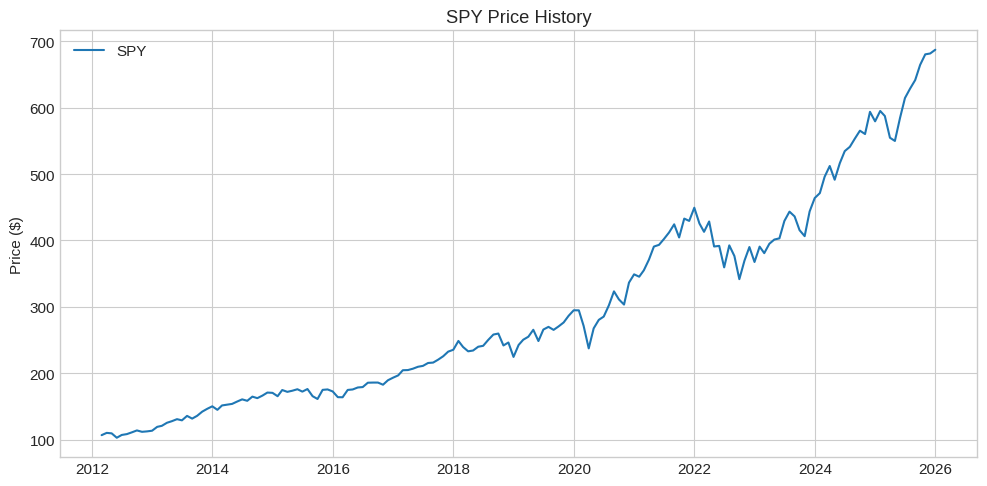

In [16]:
# The basic pattern we will use throughout this book
fig, ax = plt.subplots(figsize=(10, 5))

# Plot data on the axes
ax.plot(df_prices['SPY'], label='SPY')

# Configure the axes
ax.set_title('SPY Price History')
ax.set_ylabel('Price ($)')
ax.set_xlabel('')
ax.legend()

# Finalize and display
plt.tight_layout()
plt.show()

Notice the pattern:
1. Create figure and axes: `fig, ax = plt.subplots()`
2. Plot data: `ax.plot(...)`
3. Configure appearance: `ax.set_title(...)`, `ax.set_ylabel(...)`
4. Display: `plt.tight_layout()` then `plt.show()`

This pattern will repeat throughout every visualization we create.

### 3.4 Multiple Plots with Subplots

The real power of the object-oriented approach emerges with multiple plots. The `plt.subplots()` function can create a grid of axes in one call.

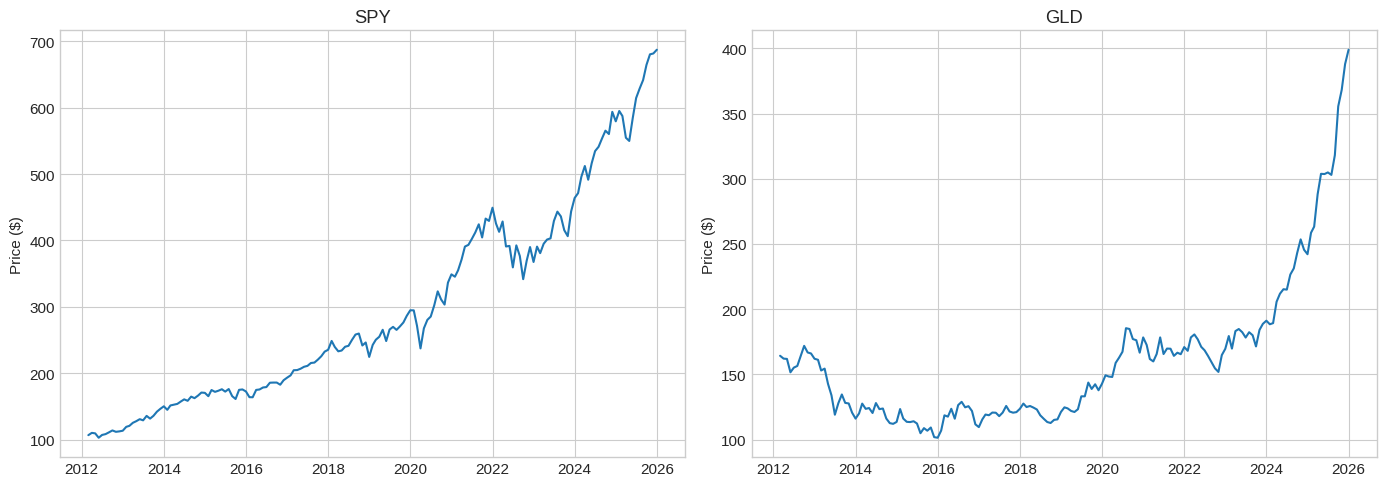

In [17]:
# Create a 1x2 grid (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot
axes[0].plot(df_prices['SPY'])
axes[0].set_title('SPY')
axes[0].set_ylabel('Price ($)')

# Right plot
axes[1].plot(df_prices['GLD'])
axes[1].set_title('GLD')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

With a 2D grid, you access individual axes using two indices: `axes[row, col]`. For example, `axes[0, 1]` refers to the first row, second column.

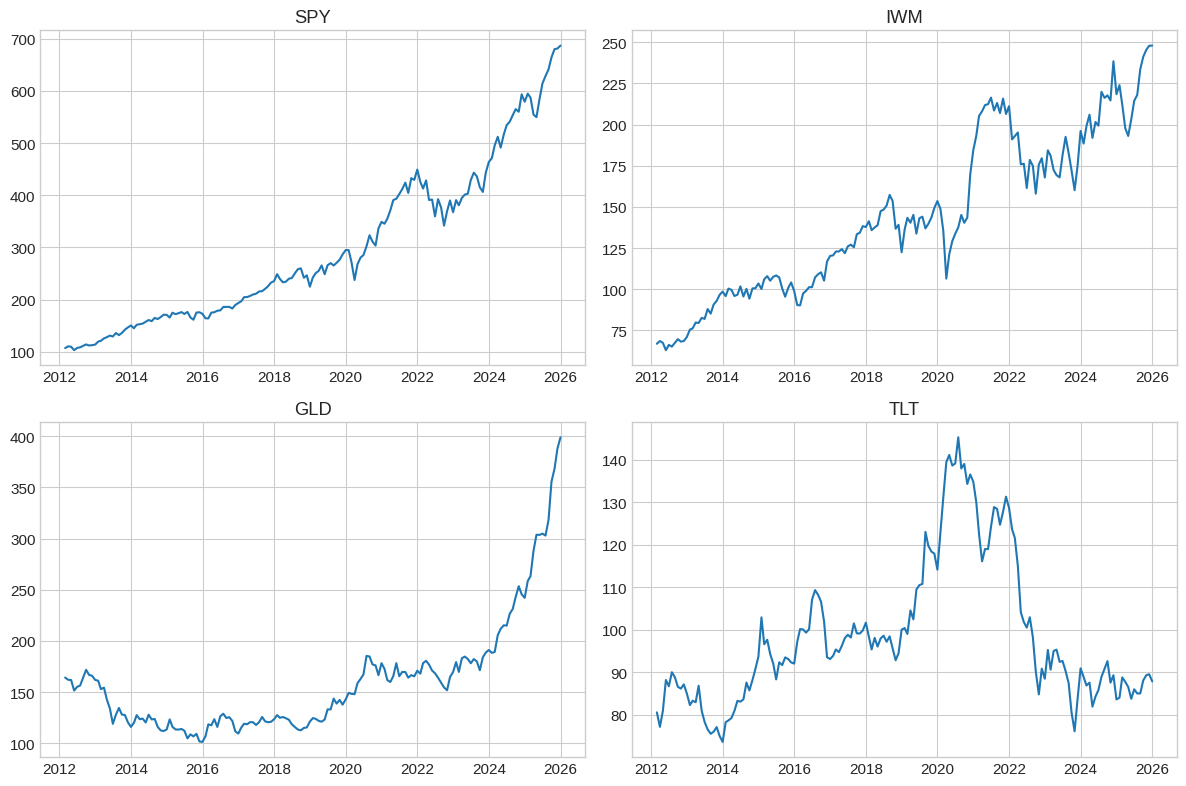

In [18]:
# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Access each subplot by row, column
axes[0, 0].plot(df_prices['SPY'])
axes[0, 0].set_title('SPY')

axes[0, 1].plot(df_prices['IWM'])
axes[0, 1].set_title('IWM')

axes[1, 0].plot(df_prices['GLD'])
axes[1, 0].set_title('GLD')

axes[1, 1].plot(df_prices['TLT'])
axes[1, 1].set_title('TLT')

plt.tight_layout()
plt.show()

**Tip:** For grids, you can flatten the axes array to iterate through all subplots easily:

```python
fig, axes = plt.subplots(2, 2)
for ax, ticker in zip(axes.flatten(), tickers):
    ax.plot(df[ticker])
```

When you create a 2D grid of subplots like `fig, axes = plt.subplots(2, 2)`, the axes variable is a 2D numpy array with `shape (2, 2)`. To access individual plots, you need two indices: axes[0, 1] for row 0, column 1.

`axes.flatten()` converts this 2D array into a 1D array, so you can iterate through all subplots with a simple loop (seen above).



We will use this technique when creating multi-panel visualizations.

### 3.5 Quick Comparison

Here is the same plot using both interfaces, so you can see the difference in syntax:

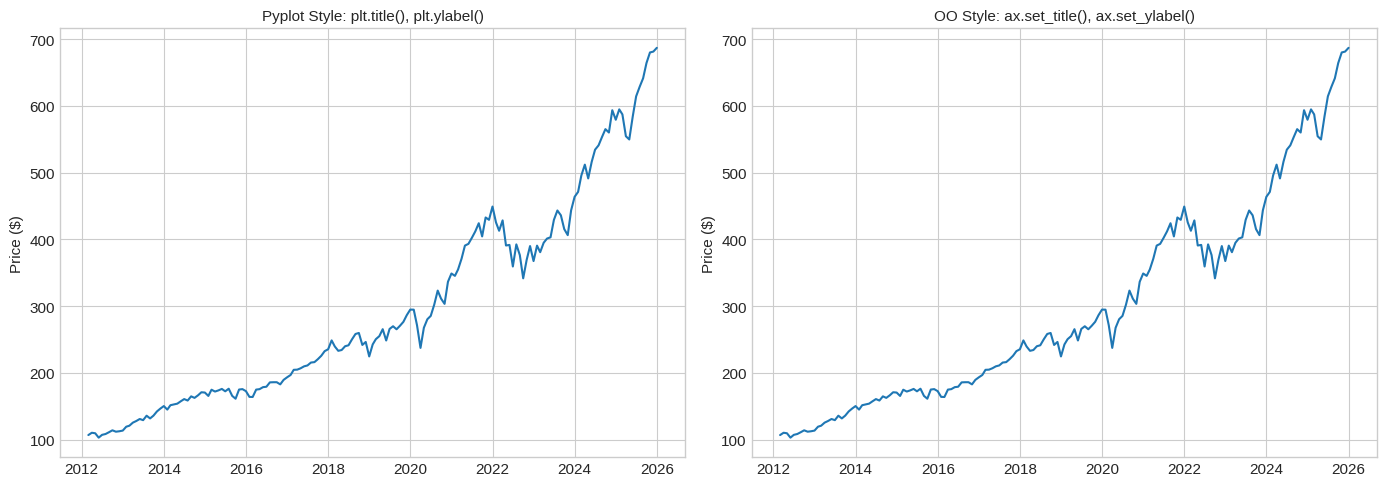

In [19]:
# Side by side comparison of both interfaces
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: What pyplot style looks like (for reference only)
# plt.plot(df_prices['SPY'])
# plt.title('Pyplot Style')
# plt.ylabel('Price')

# We'll create both using fig, ax to show them together
axes[0].plot(df_prices['SPY'])
axes[0].set_title('Pyplot Style: plt.title(), plt.ylabel()', fontsize=11)
axes[0].set_ylabel('Price ($)')

axes[1].plot(df_prices['SPY'])
axes[1].set_title('OO Style: ax.set_title(), ax.set_ylabel()', fontsize=11)
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

**Key syntax differences:**

| Pyplot (`plt.`) | Object-Oriented (`ax.`) |
|-----------------|-------------------------|
| `plt.plot()` | `ax.plot()` |
| `plt.title()` | `ax.set_title()` |
| `plt.xlabel()` | `ax.set_xlabel()` |
| `plt.ylabel()` | `ax.set_ylabel()` |
| `plt.xlim()` | `ax.set_xlim()` |
| `plt.legend()` | `ax.legend()` |

From this point forward, all plots in this book will use the `fig, ax` pattern.

---

### Section Summary

In this section, we covered:

1. **Two interfaces:** Pyplot (`plt.`) for quick plots, object-oriented (`fig, ax`) for control
2. **Why `fig, ax`:** Explicit control, scales to complexity, professional standard
3. **Terminology:** Figure (canvas), Axes (plot area), Axis (x or y axis)
4. **The pattern:** Create with `plt.subplots()`, configure with `ax.set_*()`, display with `plt.show()`
5. **Subplots:** Access via indexing (`axes[0]` or `axes[row, col]`)

With this foundation, we are ready to create visualizations.

---

## Section 4: Time-Series Plots

Time-series plots are the foundation of financial analysis. They show how values change over time and reveal patterns that summary statistics cannot capture: trends, cycles, volatility clusters, and regime changes.

**When to use time-series plots:**
- To visualize price or return history
- To identify trends, cycles, or structural breaks
- To compare multiple assets over the same period
- To spot volatility clusters (periods of high/low turbulence)

**Key information you extract:**
- Long-term direction (upward, downward, sideways)
- Relative performance across assets
- Timing of major moves and crises
- Volatility regimes

### 3.1 Basic Line Plot

The simplest time-series visualization is a single line showing one variable over time. Pandas DataFrames have a built-in `.plot()` method that creates matplotlib figures with sensible defaults.

**When to use:** When you want to examine one asset in isolation before comparing to others.

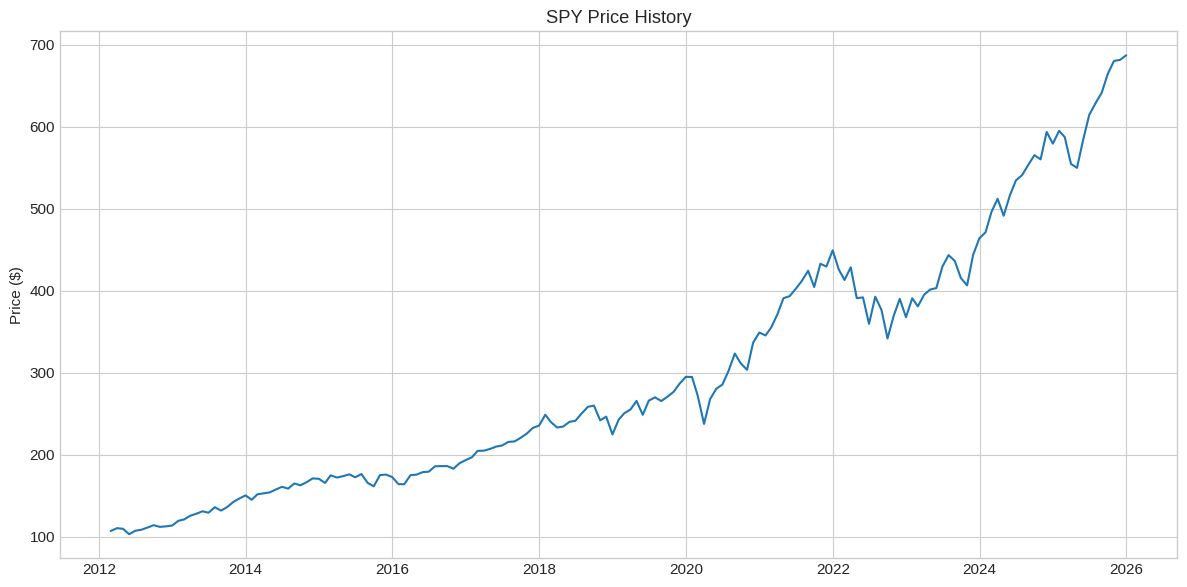

In [20]:
# Basic line plot - SPY prices
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_prices['SPY'])
ax.set_title('SPY Price History')
ax.set_ylabel('Price ($)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

The upward trend is immediately visible. You can also see periods of drawdown (2018, 2020, 2022) that were not apparent from the summary statistics alone. This is the value of visualization: it shows the path, not just the endpoints.

### 3.2 Multi-Line Plot

Plotting multiple series on the same axes lets you compare their movements directly. However, this only works well when the series have similar scales.

**When to use:** When comparing assets with similar price levels or when plotting returns (which are naturally on the same scale).

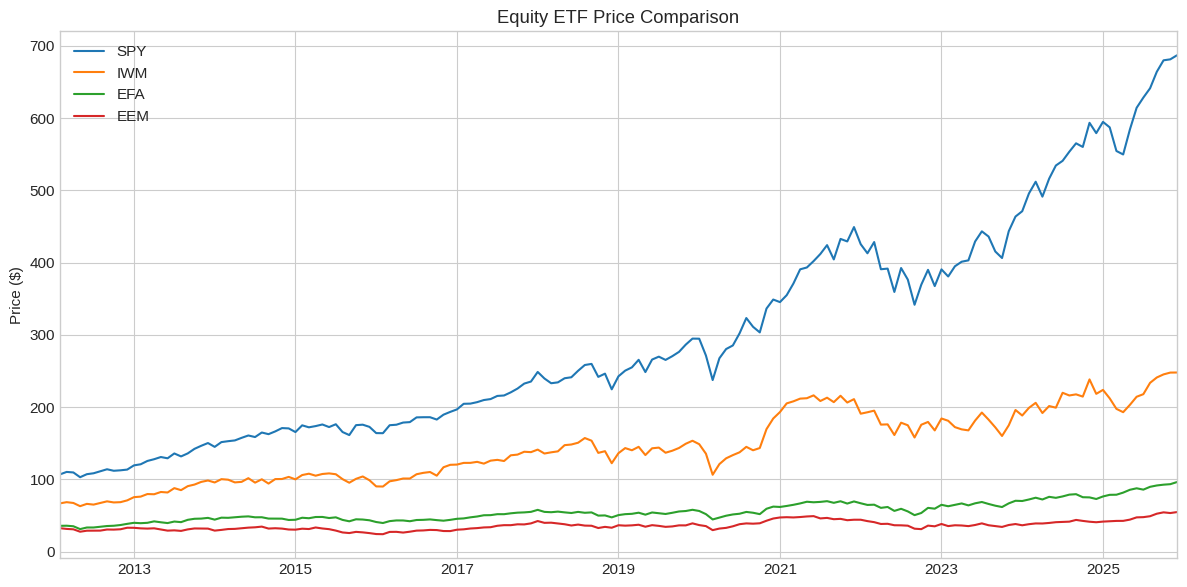

In [21]:
# Multi-line plot - all equity ETFs
equity_tickers = ['SPY', 'IWM', 'EFA', 'EEM']

fig, ax = plt.subplots(figsize=(12, 6))
df_prices[equity_tickers].plot(ax=ax)
ax.set_title('Equity ETF Price Comparison')
ax.set_ylabel('Price ($)')
ax.set_xlabel('')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**The problem:** SPY's price is much higher than the others, compressing the other lines at the bottom. This makes it impossible to compare their relative performance. We cannot tell if EEM went up 50% or 5%.

This is a fundamental issue when comparing assets with different price levels. We will address it with normalization in Section 3.4.

### 3.3 Subplots (Multi-Panel)

When assets have very different scales, subplots let you give each its own y-axis while maintaining a common time axis for comparison.

**When to use:** When you want to show multiple assets that cannot share a y-axis, or when you want to examine each series individually while keeping them visually aligned in time.

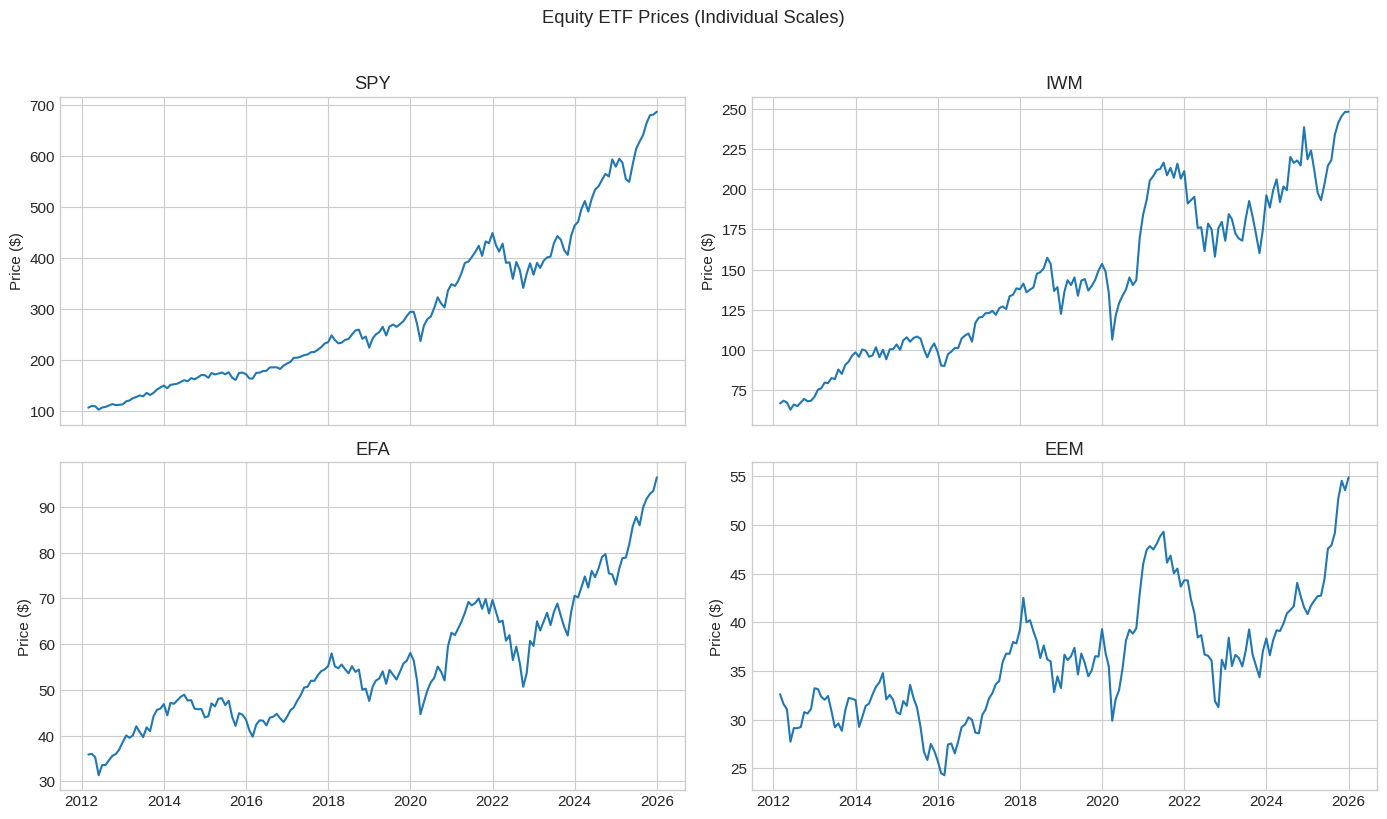

In [22]:
# Subplots - each asset gets its own panel
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, ticker in enumerate(equity_tickers):
    axes[i].plot(df_prices.index, df_prices[ticker])
    axes[i].set_title(ticker)
    axes[i].set_ylabel('Price ($)')

plt.suptitle('Equity ETF Prices (Individual Scales)', y=1.02)
plt.tight_layout()
plt.show()

Now each asset has its own scale, and we can see the shape of each price history clearly. The shared x-axis (`sharex=True`) ensures that time aligns across all panels, making it easy to see how different assets behaved during the same periods (e.g., the 2020 crash is visible in all four panels at the same horizontal position).

### 3.4 Normalized Prices (Rebasing to 100)

The best way to compare performance across assets with different price levels is to normalize them to a common starting point. By setting all prices to 100 at the start date, subsequent values show cumulative percentage growth.

**When to use:** Whenever you want to compare relative performance across assets with different price levels. This is the industry standard for performance comparison charts.

**How to read it:** If a line moves from 100 to 150, the asset gained 50%. If it moves from 100 to 80, it lost 20%.

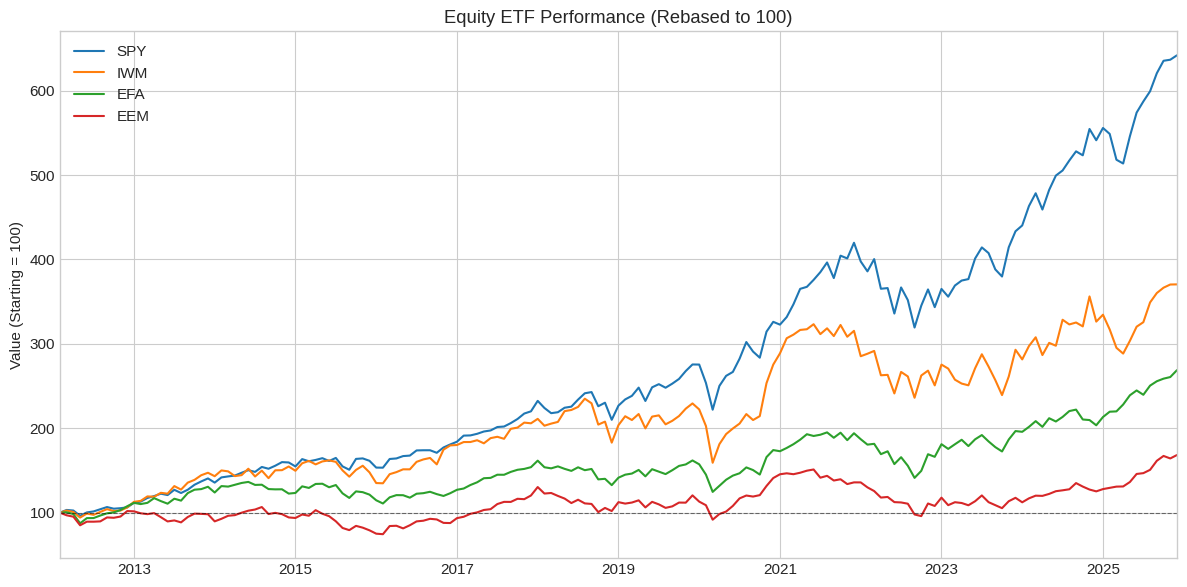

In [23]:
# Normalize prices to start at 100
df_normalized = (df_prices / df_prices.iloc[0]) * 100

# Plot normalized equity prices
fig, ax = plt.subplots(figsize=(12, 6))
df_normalized[equity_tickers].plot(ax=ax)
ax.set_title('Equity ETF Performance (Rebased to 100)')
ax.set_ylabel('Value (Starting = 100)')
ax.set_xlabel('')
# This next line will add a horizontal line at y=100. You can control line style, width and color.
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

Now the comparison is clear. All assets start at the same point, and we can directly see which ones outperformed. The horizontal dashed line at 100 marks the starting value, making it easy to see cumulative gains (above the line) and losses (below).

This chart immediately reveals what the summary statistics told us: SPY has significantly outperformed the other equity markets over this period.

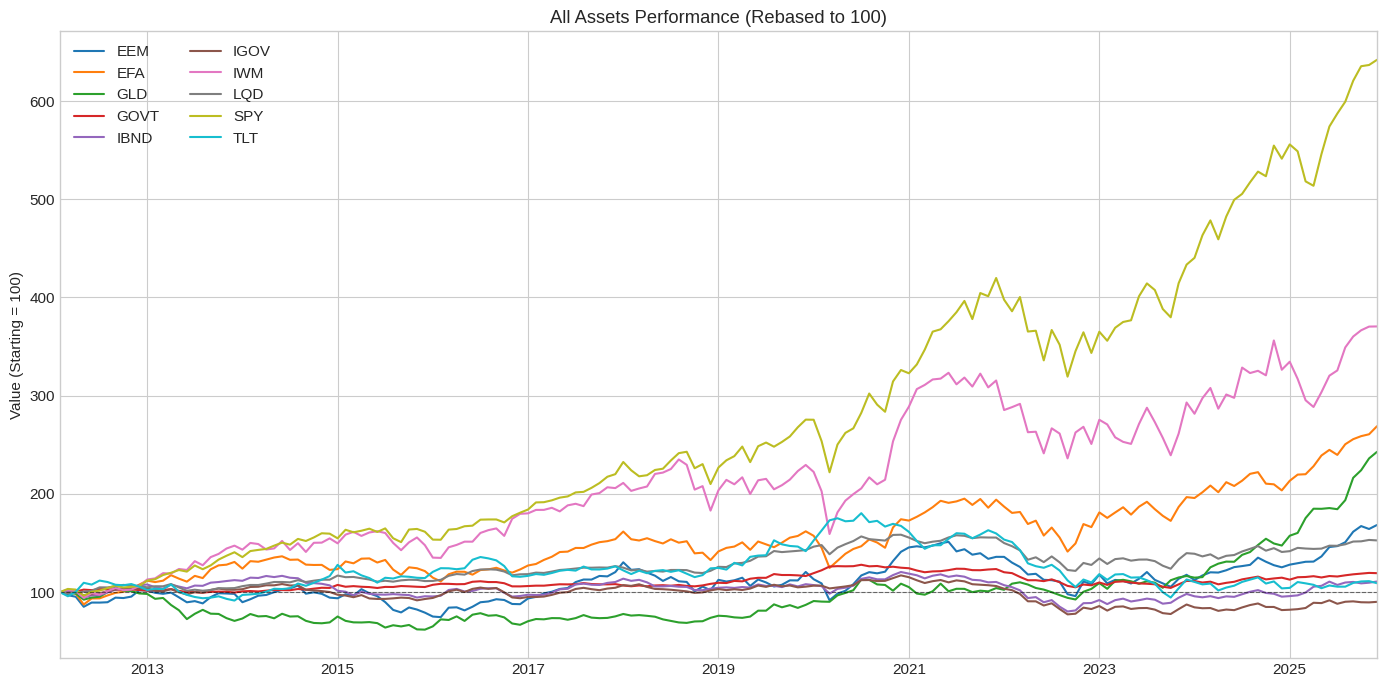

In [24]:
# Plot all 10 assets normalized
fig, ax = plt.subplots(figsize=(14, 7))
df_normalized.plot(ax=ax)
ax.set_title('All Assets Performance (Rebased to 100)')
ax.set_ylabel('Value (Starting = 100)')
ax.set_xlabel('')
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

With all 10 assets on one chart, the divergence in performance becomes striking. The equity assets cluster at the top, bonds in the middle, and IGOV at the bottom with negative total return. This single chart tells the story of the period more effectively than any table of numbers.

### 3.5 Log Scale

When values span a very wide range or when you want to focus on percentage changes rather than absolute changes, a logarithmic y-axis is useful.

**When to use:**
- When data spans multiple orders of magnitude
- When you want equal vertical distances to represent equal percentage changes
- When examining long time horizons with compounding growth

**How to read it:** On a log scale, a straight line represents constant percentage growth. Equal vertical distances represent equal percentage changes (not equal absolute changes).

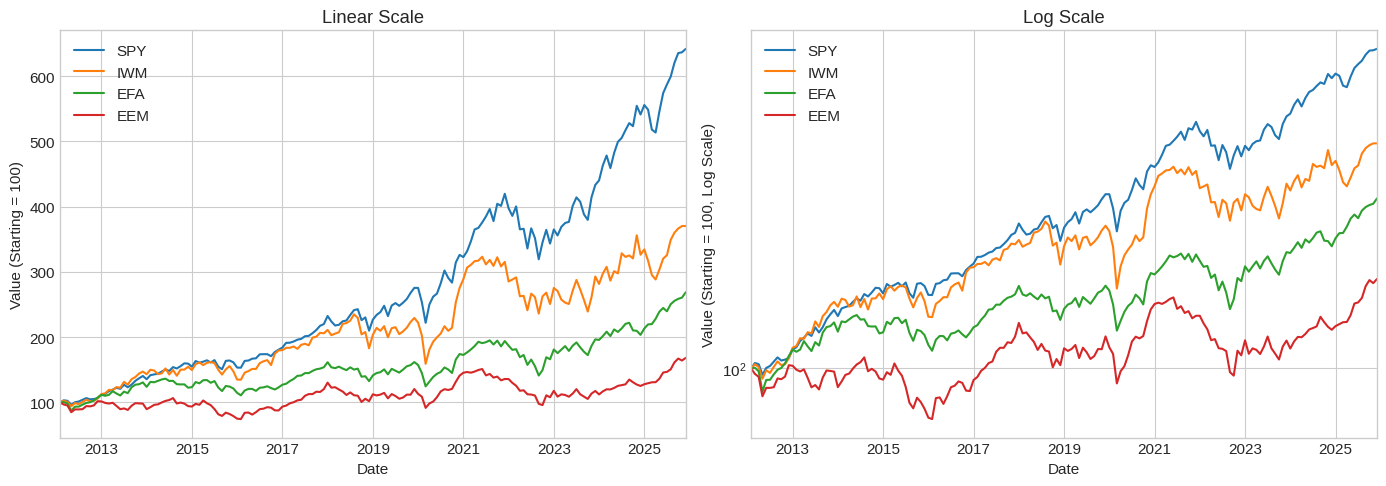

In [25]:
# Compare linear vs log scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
df_normalized[equity_tickers].plot(ax=axes[0], title='Linear Scale')
axes[0].set_ylabel('Value (Starting = 100)')
axes[0].legend(loc='upper left')

# Log scale
df_normalized[equity_tickers].plot(ax=axes[1], title='Log Scale')
axes[1].set_yscale('log')
axes[1].set_ylabel('Value (Starting = 100, Log Scale)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

On the linear scale (left), SPY's outperformance visually dominates the chart. On the log scale (right), the percentage moves are more comparable. Notice how the 2020 crash looks similar in magnitude across all assets on the log scale because they all fell by similar percentages, even though the absolute dollar amounts were very different.

Log scale is particularly important when examining assets that decay structurally over time (like VIXY in our use case) or when comparing assets over very long time horizons.

### 3.6 Cumulative Returns (Investment Growth)

Another common way to visualize performance is through cumulative returns. This shows the growth of a hypothetical $1 (or $100) investment over time.

**When to use:** When you want to show investment growth in dollar terms or when presenting to audiences who think in terms of "what would my money have become?"

**Calculation:** Cumulative return = (1 + r1) x (1 + r2) x ... x (1 + rn) - 1, which in pandas is `(1 + returns).cumprod() - 1`.

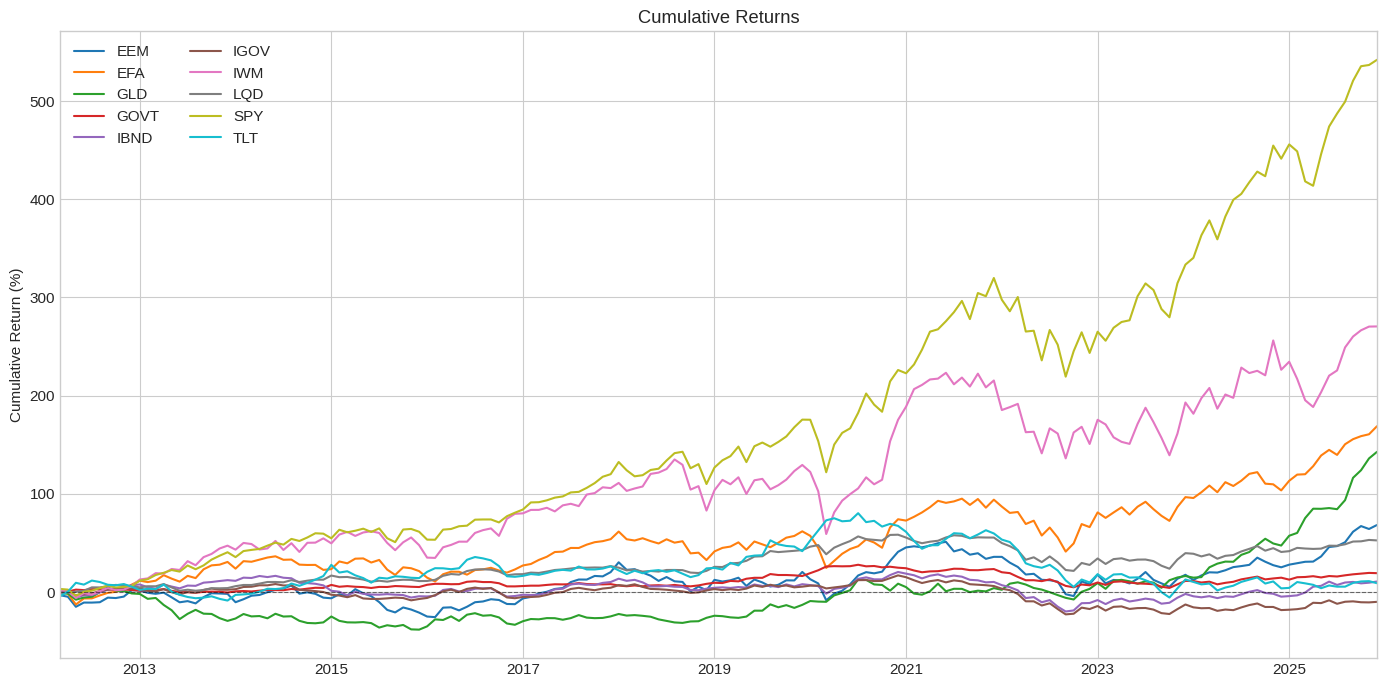

In [26]:
# Calculate cumulative returns
df_cumulative = (1 + df_returns).cumprod() - 1

# Plot cumulative returns as percentages
fig, ax = plt.subplots(figsize=(14, 7))
(df_cumulative * 100).plot(ax=ax)
ax.set_title('Cumulative Returns')
ax.set_ylabel('Cumulative Return (%)')
ax.set_xlabel('')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

This is mathematically equivalent to the normalized price chart (they will look identical), but the y-axis is labeled as percentage return rather than index value. Some audiences prefer one framing over the other.

The choice between "rebased to 100" and "cumulative return" is a matter of presentation preference. Use whichever is more intuitive for your audience.

---

## Section 5: Customizing Plots

The default matplotlib plots are functional but not publication-ready. Learning to customize colors, labels, legends, and layout will help you create clear, professional visualizations.

**Why customization matters:**
- Clear labels prevent misinterpretation
- Consistent styling builds trust
- Good design helps your audience focus on the data, not the decoration

### 4.1 Bad vs. Good: A Comparison

Let us start by looking at what makes a chart hard to read, then fix each problem. This is the most effective way to learn good visualization practices.

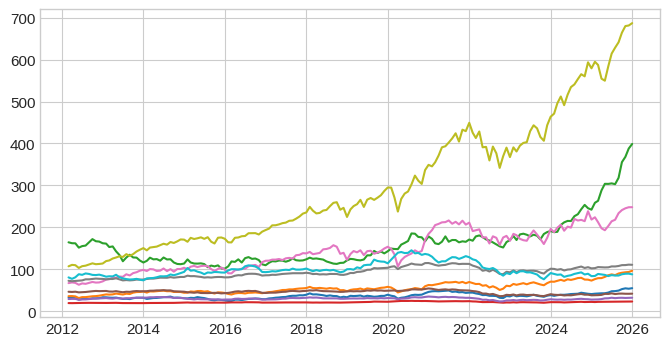

In [27]:
# BAD EXAMPLE - common mistakes
plt.figure(figsize=(8, 4))
for ticker in df_prices.columns:
    plt.plot(df_prices[ticker])
plt.show()

**Problems with this chart:**
- No title: What are we looking at?
- No axis labels: What units are these?
- No legend: Which line is which?
- Poor size: Too small to see detail
- Different scales: Some lines are crushed at the bottom
- Default colors: Hard to distinguish 10 similar colors

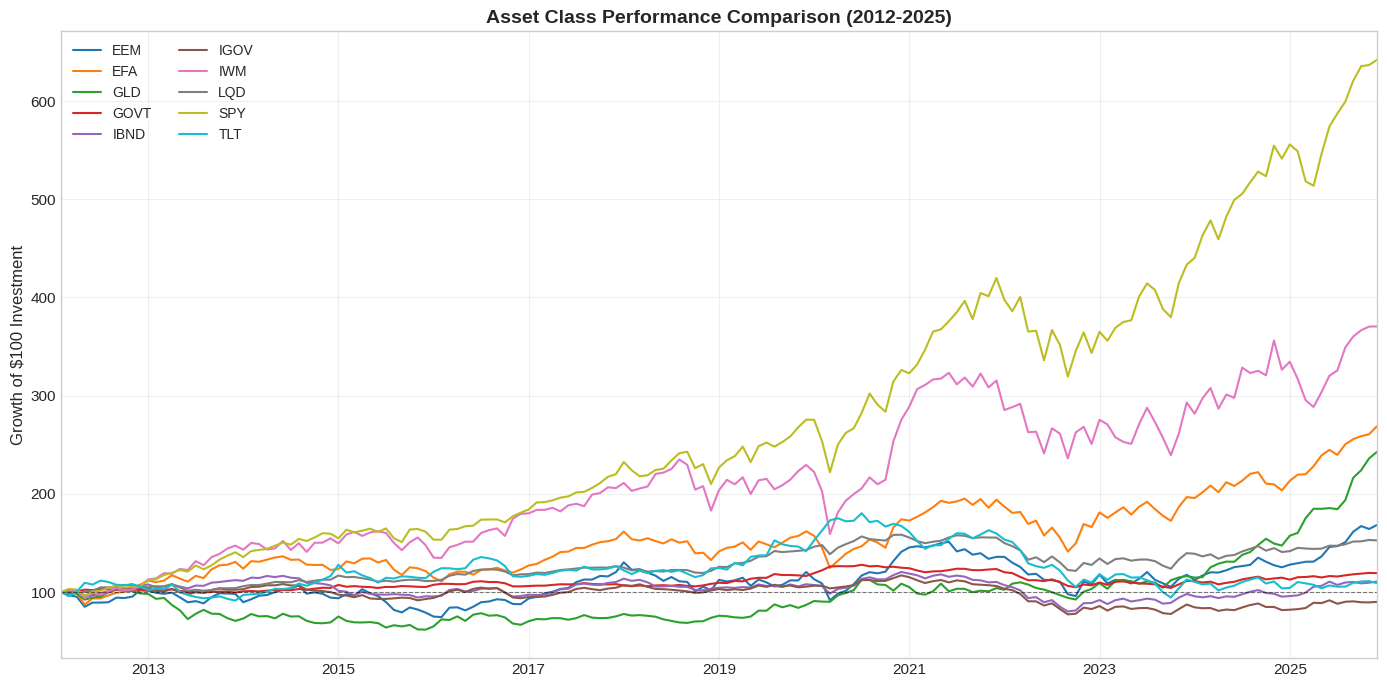

In [28]:
# GOOD EXAMPLE - fixed version
fig, ax = plt.subplots(figsize=(14, 7))

# Use normalized data so all assets are comparable
df_normalized.plot(ax=ax, linewidth=1.5)

# Clear title
ax.set_title('Asset Class Performance Comparison (2012-2025)', fontsize=14, fontweight='bold')

# Axis labels
ax.set_ylabel('Growth of $100 Investment', fontsize=12)
ax.set_xlabel('')  # Date is self-evident from the axis

# Reference line
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='_nolegend_')

# Legend outside the plot area
ax.legend(loc='upper left', ncol=2, fontsize=10, framealpha=0.9)

# Grid for readability
ax.grid(True, alpha=0.3)

# Clean layout
plt.tight_layout()
plt.show()

**Improvements made:**
- Clear, descriptive title with date range
- Y-axis label explains what the numbers mean
- Legend identifies each line
- Larger figure size for readability
- Normalized data so all assets are comparable
- Reference line at 100 for quick assessment
- Subtle grid aids reading values

### 4.2 Colors and Palettes

When you have many series, default colors can be hard to distinguish. Seaborn provides color palettes designed for better differentiation.

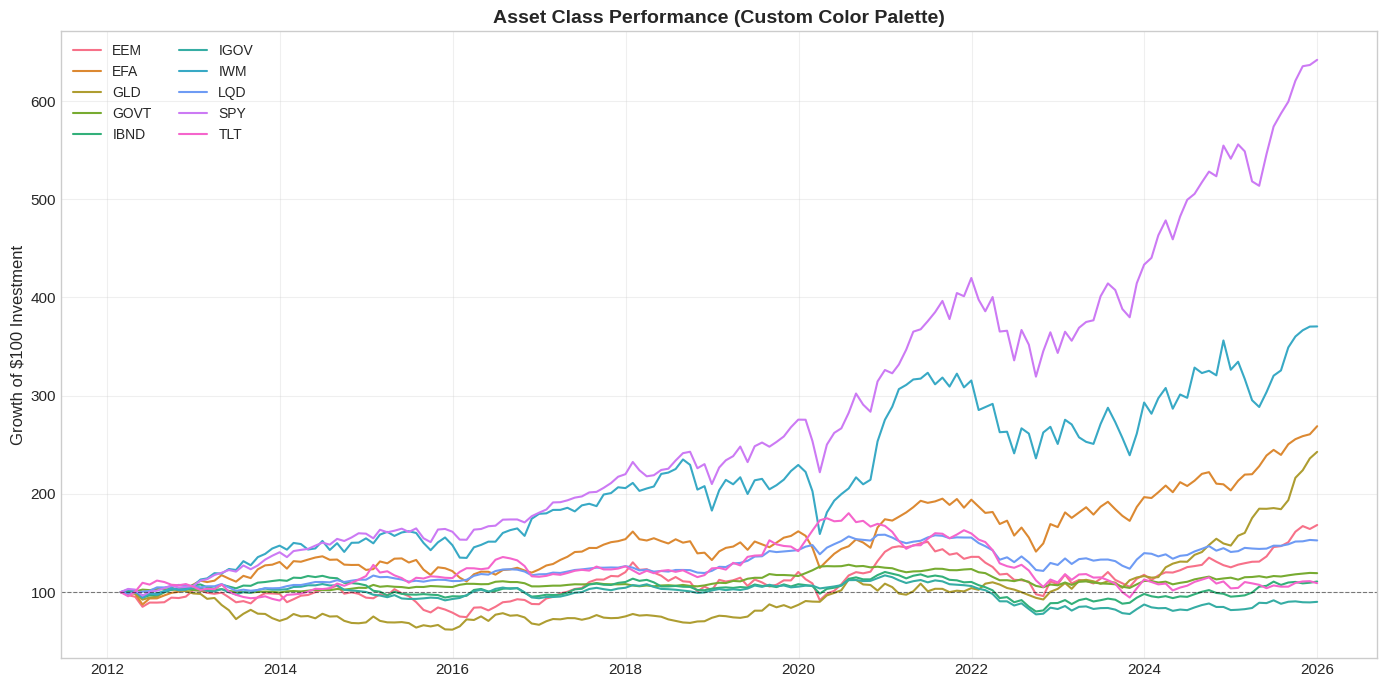

In [29]:
# Using a seaborn color palette
colors = sns.color_palette('husl', n_colors=len(df_normalized.columns))

fig, ax = plt.subplots(figsize=(14, 7))

for i, ticker in enumerate(df_normalized.columns):
    ax.plot(df_normalized.index, df_normalized[ticker], color=colors[i], label=ticker, linewidth=1.5)

ax.set_title('Asset Class Performance (Custom Color Palette)', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $100 Investment', fontsize=12)
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper left', ncol=2, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The "husl" palette provides colors that are perceptually distinct. Other useful palettes include:
- `"tab10"` - Default matplotlib, good for up to 10 categories
- `"Set2"` - Softer colors, good for presentations
- `"colorblind"` - Designed for color vision deficiency accessibility

### 4.3 Highlighting Specific Series

Sometimes you want to draw attention to one or two series while keeping the others visible for context. You can do this by varying line width, color intensity, or using a different style.

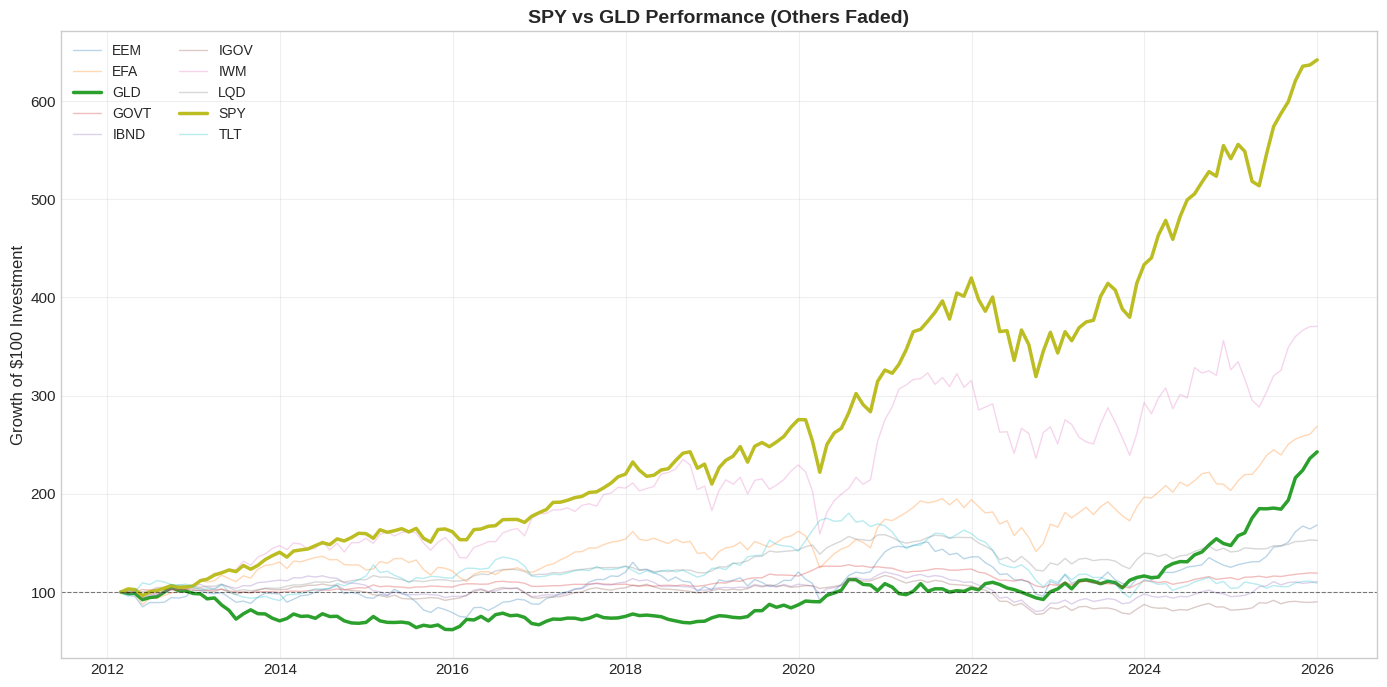

In [30]:
# Highlight SPY and GLD, fade others
fig, ax = plt.subplots(figsize=(14, 7))

highlight_tickers = ['SPY', 'GLD']

for ticker in df_normalized.columns:
    if ticker in highlight_tickers:
        ax.plot(df_normalized.index, df_normalized[ticker],
                label=ticker, linewidth=2.5, alpha=1.0)
    else:
        ax.plot(df_normalized.index, df_normalized[ticker],
                label=ticker, linewidth=1.0, alpha=0.3)

ax.set_title('SPY vs GLD Performance (Others Faded)', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $100 Investment', fontsize=12)
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper left', ncol=2, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

By reducing the alpha (transparency) and line width of non-highlighted series, we keep them visible for context while directing the viewer's attention to the comparison we want to emphasize.

### 4.4 Saving Figures

To use your charts in reports or presentations, you need to save them as image files. The key parameter is `dpi` (dots per inch), which controls resolution.

Saved: equity_performance.png (150 dpi)
Saved: equity_performance_hires.png (300 dpi)


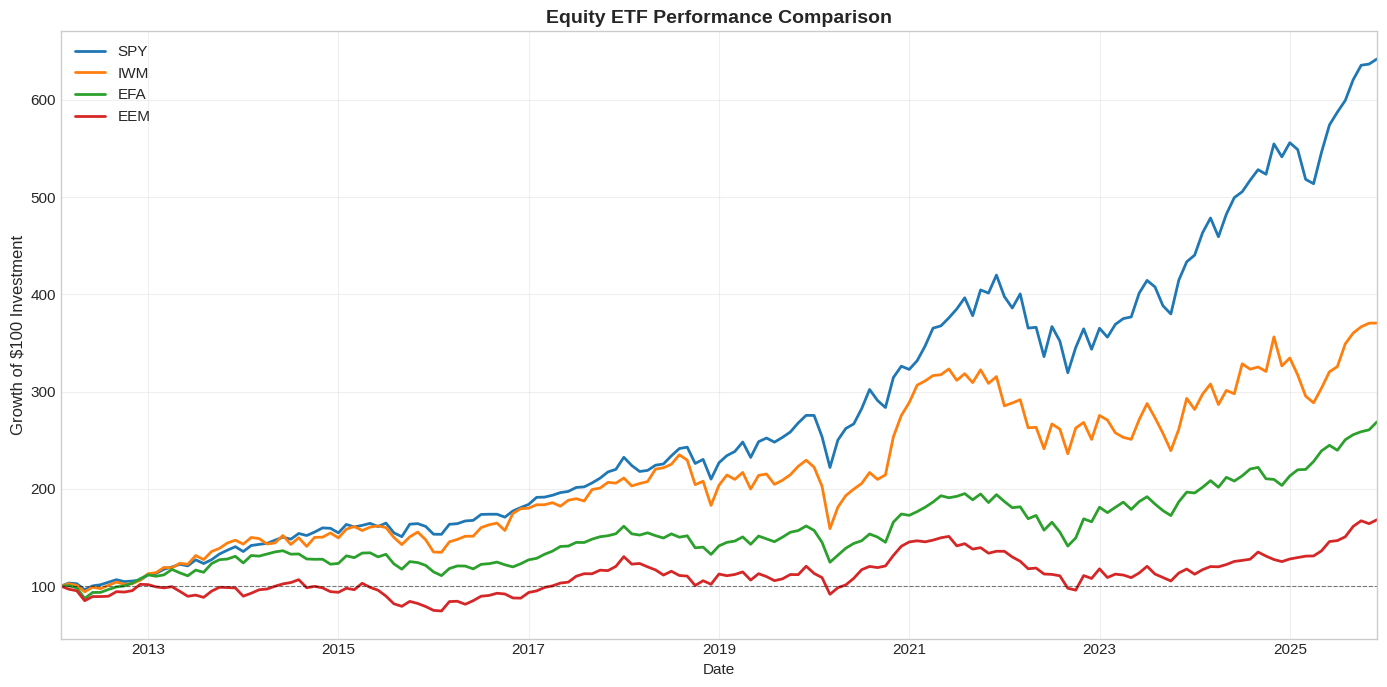

In [31]:
# Create a publication-quality figure
fig, ax = plt.subplots(figsize=(14, 7))

df_normalized[equity_tickers].plot(ax=ax, linewidth=2)
ax.set_title('Equity ETF Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $100 Investment', fontsize=12)
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save in different formats
fig.savefig('equity_performance.png', dpi=150, bbox_inches='tight')  # For web/screen
fig.savefig('equity_performance_hires.png', dpi=300, bbox_inches='tight')  # For print
# fig.savefig('equity_performance.pdf', bbox_inches='tight')  # Vector format for publications

print("Saved: equity_performance.png (150 dpi)")
print("Saved: equity_performance_hires.png (300 dpi)")
plt.show()

**DPI guidelines:**
- 72-100 dpi: Screen/web display
- 150 dpi: Good quality for most purposes
- 300 dpi: Print quality
- PDF format: Vector graphics, scales to any size without pixelation

The `bbox_inches='tight'` parameter removes excess whitespace around the figure.

---

## Section 6: Distribution Plots

Distribution plots show how values are spread across their range. For financial returns, the shape of the distribution tells you about risk: are extreme events rare or common? Is the distribution symmetric or skewed?

**When to use distribution plots:**
- To understand the range and frequency of returns
- To check for normality (or lack thereof)
- To compare risk profiles across assets
- To identify outliers

**Key information you extract:**
- Central tendency (where values cluster)
- Spread (how wide the distribution is)
- Skewness (asymmetry)
- Tail behavior (frequency of extreme values)

### 5.1 Histograms

A histogram divides the data range into bins and counts how many observations fall into each bin. It is the most basic distribution visualization.

**When to use:** To see the overall shape of a distribution and identify where values concentrate.

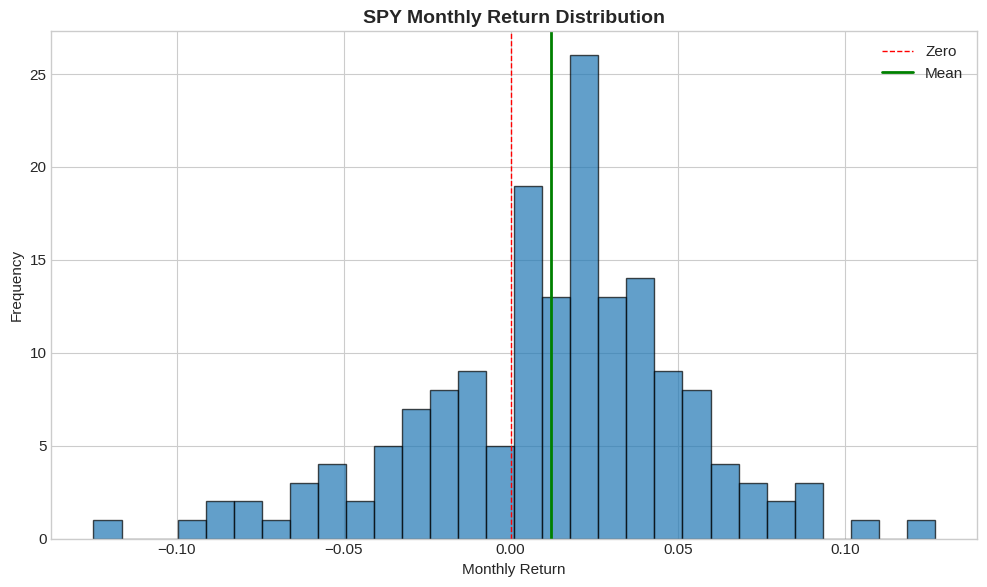

In [32]:
# Basic histogram for SPY returns
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df_returns['SPY'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero')
ax.axvline(x=df_returns['SPY'].mean(), color='green', linestyle='-', linewidth=2, label='Mean')

ax.set_title('SPY Monthly Return Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Return')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

The histogram shows that SPY returns cluster around a slightly positive mean, with most months falling between -5% and +5%. The left tail extends further than the right, hinting at the negative skewness we observed in the summary statistics.

### 5.2 Histogram with KDE Overlay

A Kernel Density Estimate (KDE) smooths the histogram into a continuous curve, making it easier to see the overall shape. Seaborn's `histplot` combines both in one function.

**When to use:** When you want a cleaner view of the distribution shape.

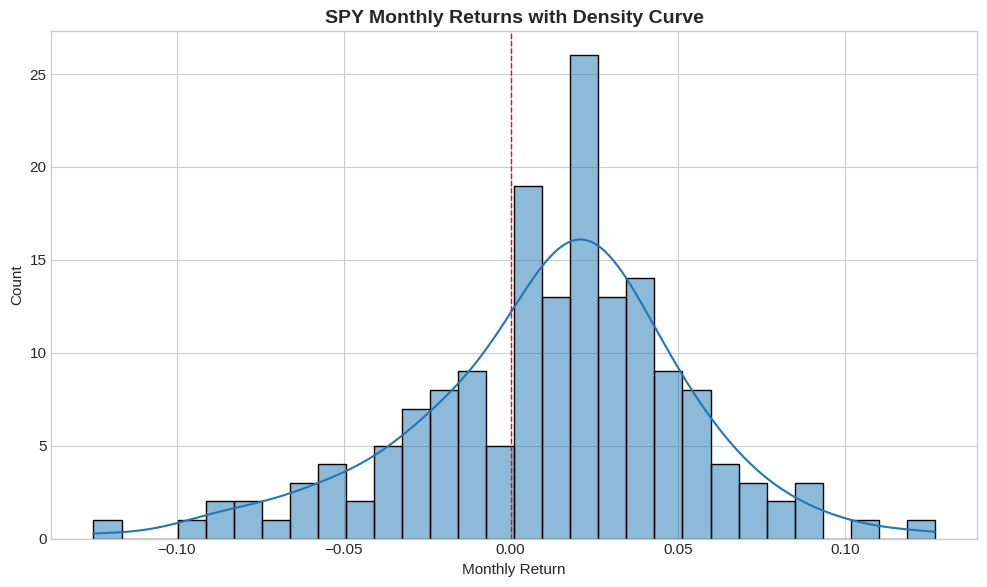

In [33]:
# Histogram with KDE overlay using Seaborn
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df_returns['SPY'], bins=30, kde=True, ax=ax)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)

ax.set_title('SPY Monthly Returns with Density Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Return')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Notice the negative skewness in the above chart that clearly shows the fat left tail. This means that there is a higher probbaility of extreme negative events compared to a normal distribution.

### 5.3 Comparing Distributions

Overlaying distributions lets you compare risk profiles directly. This is particularly useful for seeing how different asset classes behave.

**When to use:** When comparing the risk characteristics of multiple assets.

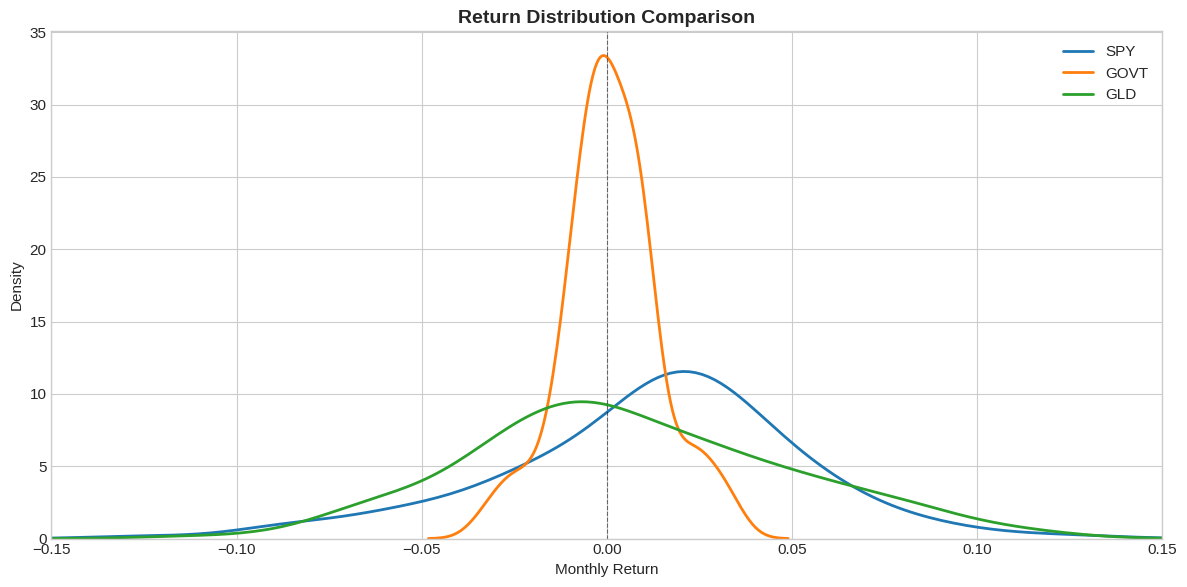

In [34]:
# Compare SPY (equity) vs GOVT (bonds) vs GLD (gold)
fig, ax = plt.subplots(figsize=(12, 6))

compare_tickers = ['SPY', 'GOVT', 'GLD']
for ticker in compare_tickers:
    sns.kdeplot(df_returns[ticker], ax=ax, label=ticker, linewidth=2)

ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Return Distribution Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Return')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(-0.15, 0.15)
plt.tight_layout()
plt.show()

The comparison reveals key differences:
- GOVT (bonds) has the tallest, narrowest peak - low volatility, returns cluster tightly around zero
- SPY and GLD have wider distributions - higher volatility, more variable returns
- All three are roughly centered near zero, but their spreads differ dramatically

**Some questions to ask yoursefl about the above plot:**
1. Which plot has the greatest kurtosis?
2. Explain the difference in the shifting of the peak for SPY vs. GLD?
3. Do you think GLD or SPY has greater positive/negative skewness?


**Answers**
1. GOVT has the greatest kurtosis - you can see this from the tall, sharp peak. The distribution is highly concentrated around the mean with thin tails.

2. SPY's peak is shifted slightly right of zero (positive mean return), while GLD's peak is closer to zero. This reflects SPY's stronger positive drift over the period.
3. SPY has negative skewness (left tail extends further - visible in the plot reaching toward -0.15). GLD has slight positive skewness (more symmetric, with the right tail extending slightly further). You can see SPY's distribution "leans" right with a longer left tail, while GLD is more balanced.

### 5.4 Box Plots

A box plot displays the five-number summary visually: minimum, first quartile (Q1), median, third quartile (Q3), and maximum. Outliers appear as individual points beyond the "whiskers."

**When to use:** To compare distributions across many categories at once, and to identify outliers.

**How to read it:**
- The box spans from Q1 to Q3 (the interquartile range, or IQR)
- The line inside the box is the median
- Whiskers extend to 1.5 x IQR beyond the box
- Points beyond whiskers are potential outliers

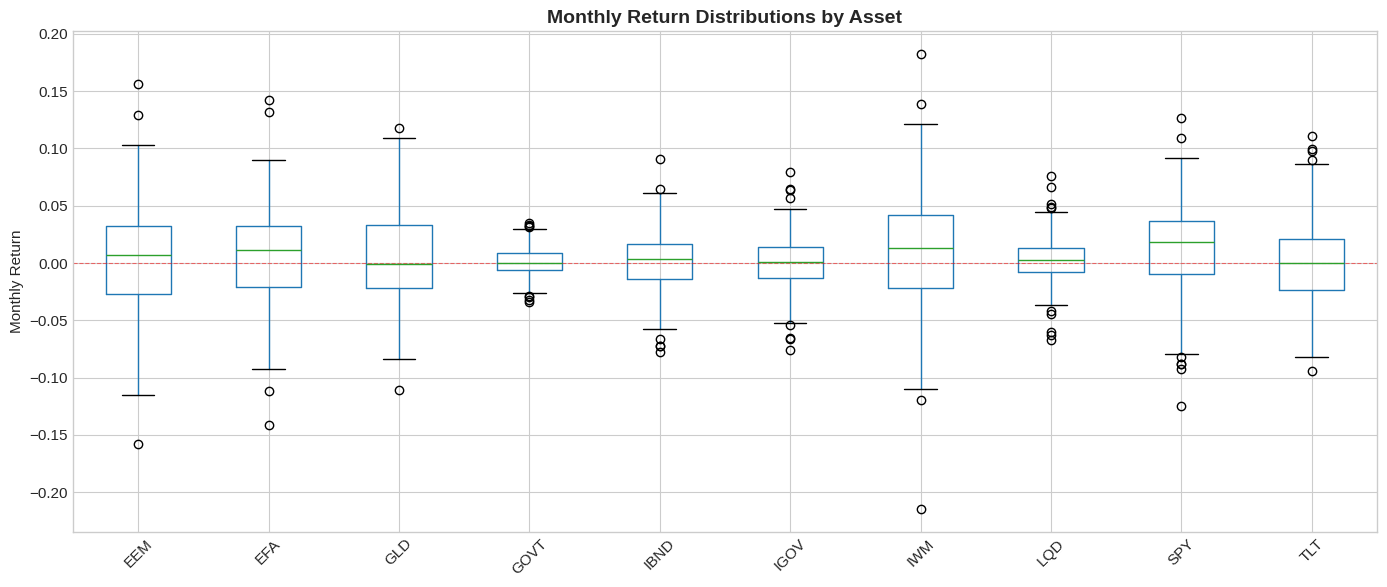

In [35]:
# Box plot for all assets
fig, ax = plt.subplots(figsize=(14, 6))

df_returns.boxplot(ax=ax)
ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Monthly Return Distributions by Asset', fontsize=14, fontweight='bold')
ax.set_ylabel('Monthly Return')
ax.set_xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The box plot immediately shows:
- GOVT has the smallest box (lowest volatility)
- IWM and EEM have the largest boxes (highest volatility)
- All assets have outliers (the dots), showing that extreme months occur for every asset class
- Most medians are near zero, but you can see slight positive bias for equities

### 5.5 Swarm Plots

A swarm plot shows every individual data point, arranged to avoid overlap. Unlike a box plot that summarizes, a swarm plot hides nothing.

**When to use:** When you want to see the actual data points, not just summaries. Best for smaller datasets (< 500 points per category).

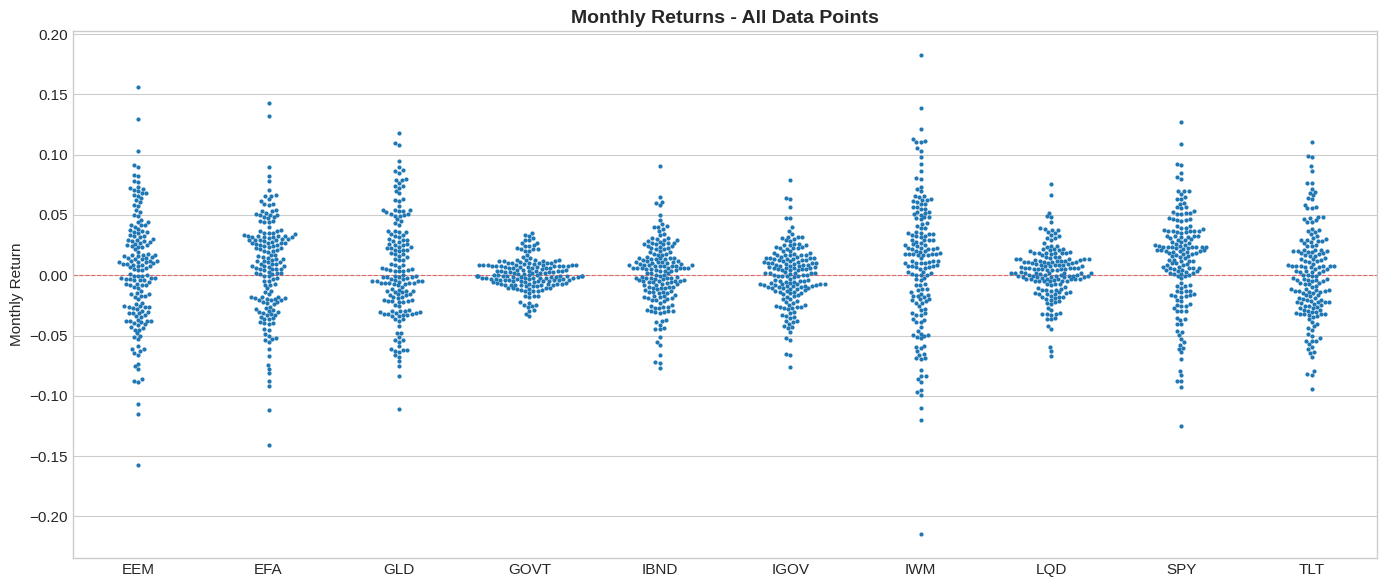

In [36]:
# Swarm plot - shows every data point
# First, melt the dataframe for seaborn
df_melted = df_returns.melt(var_name='Ticker', value_name='Return')

fig, ax = plt.subplots(figsize=(14, 6))
sns.swarmplot(data=df_melted, x='Ticker', y='Return', ax=ax, size=3)
ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Monthly Returns - All Data Points', fontsize=14, fontweight='bold')
ax.set_ylabel('Monthly Return')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

The swarm plot reveals:
- The actual density of observations at each return level
- Gaps in the distribution (ranges with no observations)
- The exact location of extreme returns

Compare this to the box plot: the swarm shows all the detail that the box plot summarizes.

### 5.6 Violin Plots

A violin plot combines a box plot with a KDE, showing both the summary statistics and the distribution shape. The width of the "violin" indicates the density of observations at each value.

**When to use:** When you want the compactness of a box plot but also want to see distribution shape (bimodality, skewness).

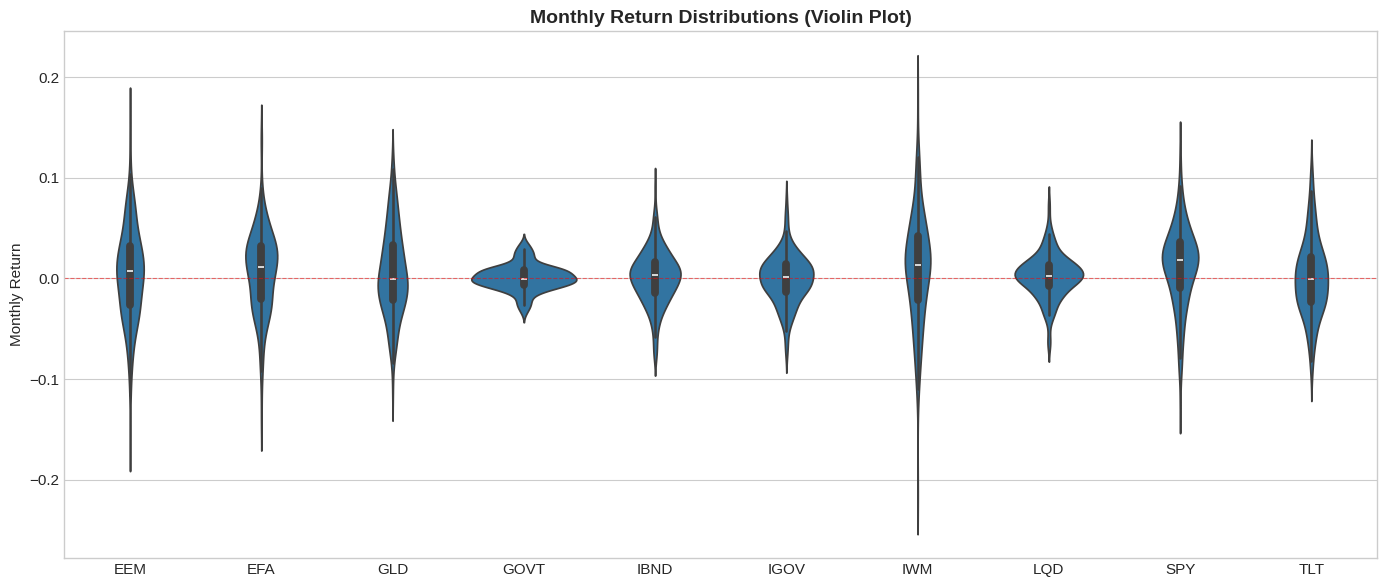

In [37]:
# Violin plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(data=df_melted, x='Ticker', y='Return', ax=ax, inner='box')
ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Monthly Return Distributions (Violin Plot)', fontsize=14, fontweight='bold')
ax.set_ylabel('Monthly Return')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

The violin plot shows:
- Distribution shape: GOVT is tall and narrow; IWM is short and wide
- The embedded box plot shows median and quartiles
- Asymmetry: you can see if the distribution is skewed by whether the violin is symmetric

This combines the best of histograms (shape) and box plots (summary statistics) in one compact visualization.

### 5.7 QQ Plots (Quantile-Quantile)

A QQ plot compares your data's distribution to a theoretical distribution (usually normal). If the data matches the theoretical distribution, points fall on a straight diagonal line.

**When to use:** To formally assess whether your data follows a normal distribution.

**How to read it:**
- Points on the diagonal line = data matches normal distribution
- Points curving up at the right end = heavier right tail than normal (positive kurtosis)
- Points curving down at the left end = heavier left tail than normal

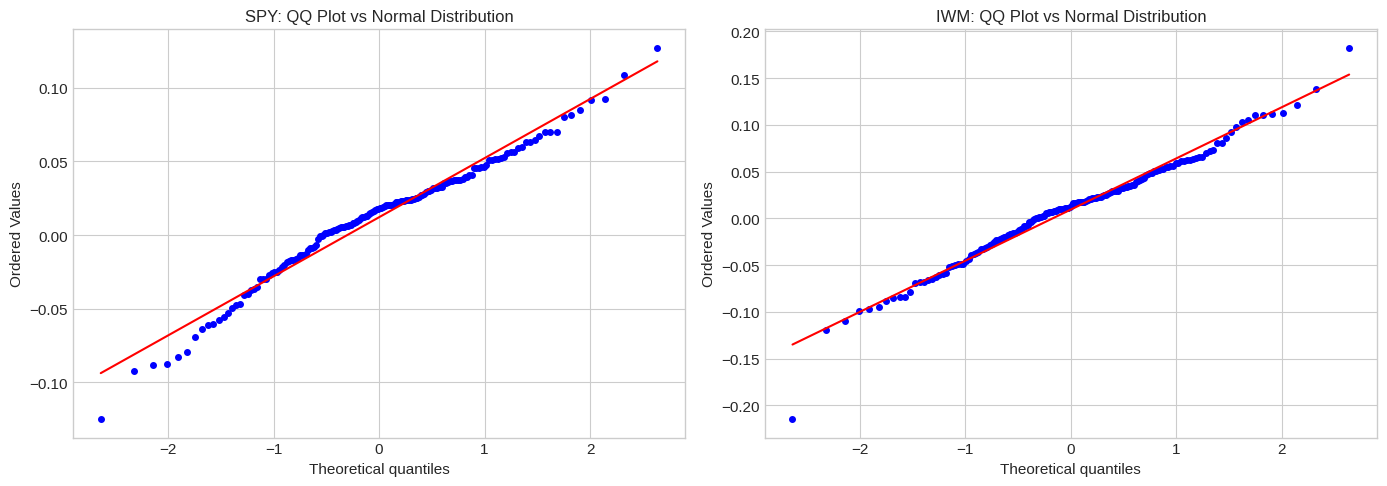

In [38]:
# QQ plot for SPY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SPY
stats.probplot(df_returns['SPY'], dist='norm', plot=axes[0])
axes[0].set_title('SPY: QQ Plot vs Normal Distribution', fontsize=12)
axes[0].get_lines()[0].set_markersize(4)

# IWM for comparison
stats.probplot(df_returns['IWM'], dist='norm', plot=axes[1])
axes[1].set_title('IWM: QQ Plot vs Normal Distribution', fontsize=12)
axes[1].get_lines()[0].set_markersize(4)

plt.tight_layout()
plt.show()

The QQ plots show:
- Both SPY and IWM deviate from the normal line at the tails
- The left tail (negative returns) falls below the line, indicating more extreme negative returns than a normal distribution would predict
- The right tail rises above the line, indicating more extreme positive returns than normal

This confirms what we saw in the kurtosis statistics: these assets have "fat tails" compared to a normal distribution. Risk models assuming normality will underestimate the frequency of extreme events.

---

## Section 7: Seaborn vs. Matplotlib

Throughout this notebook, we have used both libraries. Here is a quick comparison to help you choose.

| Aspect | Matplotlib | Seaborn |
|--------|------------|--------|
| Control | Maximum control over every element | Sensible defaults, less customization |
| Learning curve | Steeper | Gentler |
| Statistical plots | Manual implementation | Built-in (violin, swarm, etc.) |
| Styling | Requires explicit formatting | Attractive defaults |
| Best for | Custom layouts, publication figures | Quick statistical exploration |

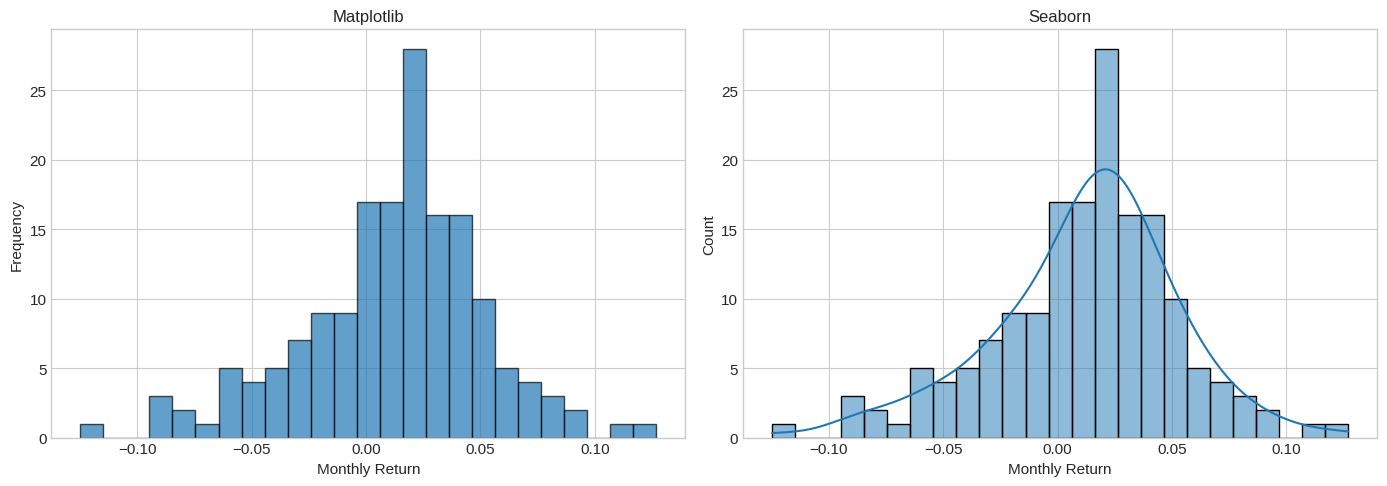

In [39]:
# Same plot in both libraries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matplotlib
axes[0].hist(df_returns['SPY'], bins=25, edgecolor='black', alpha=0.7)
axes[0].set_title('Matplotlib', fontsize=12)
axes[0].set_xlabel('Monthly Return')
axes[0].set_ylabel('Frequency')

# Seaborn
sns.histplot(df_returns['SPY'], bins=25, kde=True, ax=axes[1])
axes[1].set_title('Seaborn', fontsize=12)
axes[1].set_xlabel('Monthly Return')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Both produce similar results. Seaborn adds the KDE curve automatically with one parameter. Matplotlib requires more code but gives you complete control.

**Recommendation:** Use Seaborn for exploratory analysis and statistical plots. Switch to Matplotlib when you need precise control over the final output.

---

## Section 8: Plotly for Interactive Visualizations

Plotly creates interactive charts where you can hover for values, zoom, pan, and select. This is valuable for exploration and for sharing with colleagues who want to investigate the data themselves.

**When to use Plotly:**
- During exploration when you want to inspect specific points
- When sharing dashboards or HTML reports
- When your audience wants to interact with the data

**When to use Matplotlib/Seaborn:**
- For publication-quality static figures
- When file size matters (Plotly files are larger)
- For print output

In [40]:
# Interactive time series with Plotly
fig = px.line(df_normalized,
              title='Asset Class Performance (Interactive)',
              labels={'value': 'Growth of $100', 'Date': ''})

fig.add_hline(y=100, line_dash='dash', line_color='black', opacity=0.5)
fig.update_layout(hovermode='x unified')
fig.show()

Hover over the chart to see exact values for any date. Use the toolbar to zoom into specific periods. Double-click to reset the view.

The `hovermode='x unified'` setting shows all values for a given date in one tooltip.

In [41]:
# Interactive histogram with Plotly
fig = px.histogram(df_returns, x='SPY', nbins=30,
                   title='SPY Monthly Return Distribution (Interactive)',
                   labels={'SPY': 'Monthly Return'})

fig.add_vline(x=0, line_dash='dash', line_color='red')
fig.show()

In [42]:
# Interactive box plot with Plotly
fig = px.box(df_melted, x='Ticker', y='Return',
             title='Monthly Return Distributions (Interactive)')

fig.add_hline(y=0, line_dash='dash', line_color='red', opacity=0.5)
fig.show()

Hover over any box or outlier point to see the exact values. This is particularly useful for identifying which specific months produced the extreme returns.

---

## Notebook Summary

In this notebook, we covered the foundational techniques of exploratory data analysis:

**Numerical Summaries (Section 2):**
- `.info()` for data structure
- `.describe()` for the five-number summary
- Extended statistics with skewness and kurtosis
- Annualized metrics for industry-standard comparisons

**Time-Series Plots (Section 3):**
- Basic line plots and multi-line comparisons
- Subplots for different scales
- Normalized prices for fair comparison
- Log scale for percentage-focused analysis

**Plot Customization (Section 4):**
- Bad vs. good chart design
- Color palettes and highlighting
- Saving figures at appropriate resolution

**Distribution Plots (Section 5):**
- Histograms and KDE
- Box plots, swarm plots, and violin plots
- QQ plots for normality assessment

**Library Comparison (Sections 6-7):**
- Seaborn vs. Matplotlib tradeoffs
- Plotly for interactive exploration

**Key takeaways:**
1. Always start with numerical summaries before visualizing
2. Normalize prices when comparing assets with different price levels
3. Use the right plot for the right question
4. Financial returns are not normally distributed - they have fat tails

In the next notebook, we will explore correlation analysis and build the Range Plot, a custom visualization for comparing distributions across assets.

*Note: Please do not forget to download the parquet files from the Files section in this notebook. If you close this notebook, those files will be lost. You must download them for use in future notebooks.*